# Load the Data

In [1]:
from google.colab import drive
from shutil import copy2
import duckdb
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import plotly.express as px
from pylab import rcParams
import pandas as pd

darkmodel = False
rcParams['figure.figsize'] = (12,6)
pd.options.display.float_format = '{:,.2f}'.format

This code box is for theme in `matplotlib` like dark mode or light mode.

In [2]:
%matplotlib inline

if darkmodel:
    # 1. Define a sophisticated E-commerce color palette
    # These colors are chosen for high contrast against the #212946 background
    colors = [
        "#08F7FE",  # Cyan Glow
        "#FE53BB",  # Neon Pink
        "#F5D300",  # Cyber Yellow
        "#00ff41",  # Matrix Green
        "#9467bd",  # Royal Purple
    ]

    # 2. Enhanced Dictionary with Complex Styling
    refined_dark_style = {
        # Background and Canvas
        "figure.facecolor": "#212946",
        "axes.facecolor": "#212946",
        "savefig.facecolor": "#212946",

        # Grid Sophistication
        "axes.grid": True,
        "axes.grid.which": "both",
        "grid.color": "#2A3459",
        "grid.linewidth": "1",
        "grid.alpha": 0.5,

        # Typography & Labels (Optimized for readability)
        "text.color": "#E2E2E2",
        "axes.labelcolor": "#E2E2E2",
        "axes.labelsize": 14,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.titlepad": 20,
        "xtick.color": "#8E9CC3",
        "ytick.color": "#8E9CC3",
        "font.size": 12,

        # Spines (Clean aesthetic)
        "axes.spines.left": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2A3459",

        # Line & Marker Settings
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "axes.prop_cycle": plt.cycler(color=colors),
    }

    plt.rcParams.update(refined_dark_style)

else:
    # 1. Defining the "Paper & Ink" Palette
    # Deep Blue #003366 | Oxide Red #A52A2A
    ecom_vintage_colors = [
        "#003366",  # Oxford Blue (Primary)
        "#A52A2A",  # Oxide Red (Comparison)
        "#006400",  # Dark Green (Success Metrics)
        "#704214",  # Sepia (Neutral)
    ]

    vintage_style = {
        # Background - The specific parchment hex you requested
        "figure.facecolor": "#f7e4b7",
        "axes.facecolor": "#f7e4b7",
        "savefig.facecolor": "#f7e4b7",

        # Grid - Subtle contrast using a darker version of the background
        "axes.grid": True,
        "grid.color": "#e2d1a8",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,

        # Typography - Deep Charcoal/Blue instead of pure black for a softer feel
        "text.color": "#2C2C2C",
        "axes.labelcolor": "#2C2C2C",
        "xtick.color": "#5D5D5D",
        "ytick.color": "#5D5D5D",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.titlepad": 15,
        "font.size": 11,

        # Spines - Classic 'L-frame' for publication
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2C2C2C",
        "axes.linewidth": 1.5,

        # Data Point Styling
        "axes.prop_cycle": plt.cycler(color=ecom_vintage_colors),
        "lines.linewidth": 2.2,
        "lines.markersize": 8,
        "patch.edgecolor": "#f7e4b7", # Borders on bars/pie slices
    }

    plt.rcParams.update(vintage_style)

In [3]:
drive.mount('/content/drive')
SourceDB = '/content/drive/My Drive/Colab Notebooks/InstaCart.db'
Dest = os.path.join(os.getcwd(), 'InstaCart')
os.makedirs(Dest, exist_ok=True)
copy2(SourceDB, Dest)

os.chdir(Dest)

Mounted at /content/drive


In [4]:
IC = duckdb.connect(database='InstaCart.db')
tables = IC.execute("SHOW TABLES;").fetchdf()
#tables = IC.execute("PRAGMA show_tables;").fetchdf()
print("Tables in InstaCart.db:")
display(tables)

Tables in InstaCart.db:


,name
0,AISLE
1,DepartmentData
2,FullTrainData
3,OrderTest
4,OrderTrain
5,OrdersDetails
6,ProductsData


In [5]:
Query01 = 'SELECT * FROM FullTrainData ORDER BY Order_ID ASC, user_id ASC;'
TrainData = IC.execute(Query01).fetchdf()
display(TrainData.sample(8))

,order_id,user_id,product_id,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
996926,2461469,106248,43295,91,16,8,6,15,18.00,6,0
1213913,2998130,30500,27454,78,19,59,4,10,3.00,11,1
1108367,2739710,152672,30072,2,16,5,0,15,30.00,20,0
979475,2415270,51425,9076,116,1,6,6,09,30.00,8,0
364454,887186,119128,4957,120,16,24,6,15,13.00,14,1
1207138,2981456,58403,35652,96,20,4,2,13,26.00,4,0
167725,410620,24512,49215,92,18,6,0,14,30.00,6,0
841940,2077189,92324,6631,31,7,65,4,11,4.00,4,0


## Data Glossary
after get the data, let's make explanation of all columns by their data and names.

| Column | Data Type | Description |
| --- | --- | --- |
| order_id               | category  | Unique identifier for each order|
| user_id                | category  | Unique identifier for each user/customer|
| product_id             | category  | Unique identifier for each product|
| aisle_id               | category  | Unique identifier for product aisle location in store|
| department_id          | category  | Unique identifier for product department category|
| order_number           | int64     | Sequential order number for each user (1 = first order, higher = later)|
| order_dow              | int64     | Day of week order placed (0=Saturday, 1=Sunday, ..., 6=Friday)|
| order_hour_of_day      | category  | Hour of day when order placed (0-23)|
| days_since_prior_order | float64   | Days elapsed since user's previous order (NaN for first order)|
| add_to_cart_order      | int64     | Sequential position in cart when product added (1=first added)|
| reordered              | int64     | 1 if previously ordered by user, 0 otherwise|

# Simple Data Statistics Summary

In [6]:
CatColumn = ['order_id', 'user_id', 'product_id', 'aisle_id', 'department_id', 'order_hour_of_day']
TrainData[CatColumn] = TrainData[CatColumn].astype('category')
TrainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   order_id                1384617 non-null  category
 1   user_id                 1384617 non-null  category
 2   product_id              1384617 non-null  category
 3   aisle_id                1384617 non-null  category
 4   department_id           1384617 non-null  category
 5   order_number            1384617 non-null  int64   
 6   order_dow               1384617 non-null  int64   
 7   order_hour_of_day       1384617 non-null  category
 8   days_since_prior_order  1384617 non-null  float64 
 9   add_to_cart_order       1384617 non-null  int64   
 10  reordered               1384617 non-null  int64   
dtypes: category(6), float64(1), int64(4)
memory usage: 85.3 MB


In [7]:
TrainData.describe()

,order_number,order_dow,days_since_prior_order,add_to_cart_order,reordered
count,"1,384,617.00","1,384,617.00","1,384,617.00","1,384,617.00","1,384,617.00"
mean,17.09,2.70,17.07,8.76,0.60
std,16.61,2.17,10.43,7.42,0.49
min,4.00,0.00,0.00,1.00,0.00
25%,6.00,1.00,7.00,3.00,0.00
50%,11.00,3.00,15.00,7.00,1.00
75%,21.00,5.00,30.00,12.00,1.00
max,100.00,6.00,30.00,80.00,1.00


In [8]:
TrainData.describe(include = 'category')

,order_id,user_id,product_id,aisle_id,department_id,order_hour_of_day
count,1384617,1384617,1384617,1384617,1384617,1384617
unique,131209,131209,39123,134,21,24
top,2813632,149753,24852,83,4,14
freq,80,80,18726,150609,409087,119370


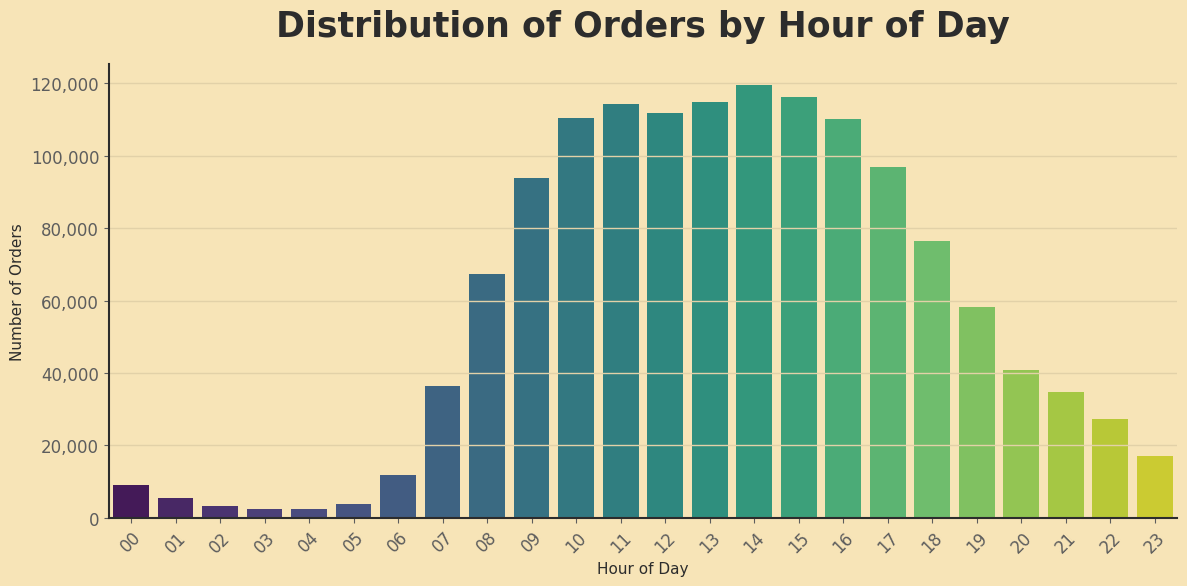

In [9]:
hour_counts = TrainData['order_hour_of_day'].value_counts().reset_index()
hour_counts.columns = ['order_hour_of_day', 'count']
hour_counts = hour_counts.sort_values('order_hour_of_day')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='order_hour_of_day',
                 y='count',
                 data=hour_counts,
                 palette='viridis',
                 hue='order_hour_of_day',
                 legend=False,
                )
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='both', which='major', labelsize=12)
plt.title('Distribution of Orders by Hour of Day', fontsize=25, pad=20)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The peak of orders occurs between 10 a.m. and 4 p.m. Advertising related to trending items should be increased during these hours to be more effective in reaching potential customers.

In [10]:
def MissingVals(Data):
    report = pd.DataFrame({
        'Missing Values': Data.isnull().sum(),
        'Percentage': (Data.isnull().sum() / len(Data)) * 100
    }).sort_values('Percentage', ascending=False)
    return report

display(MissingVals(TrainData))

,Missing Values,Percentage
order_id,0,0.00
user_id,0,0.00
product_id,0,0.00
aisle_id,0,0.00
department_id,0,0.00
order_number,0,0.00
order_dow,0,0.00
order_hour_of_day,0,0.00
days_since_prior_order,0,0.00
add_to_cart_order,0,0.00


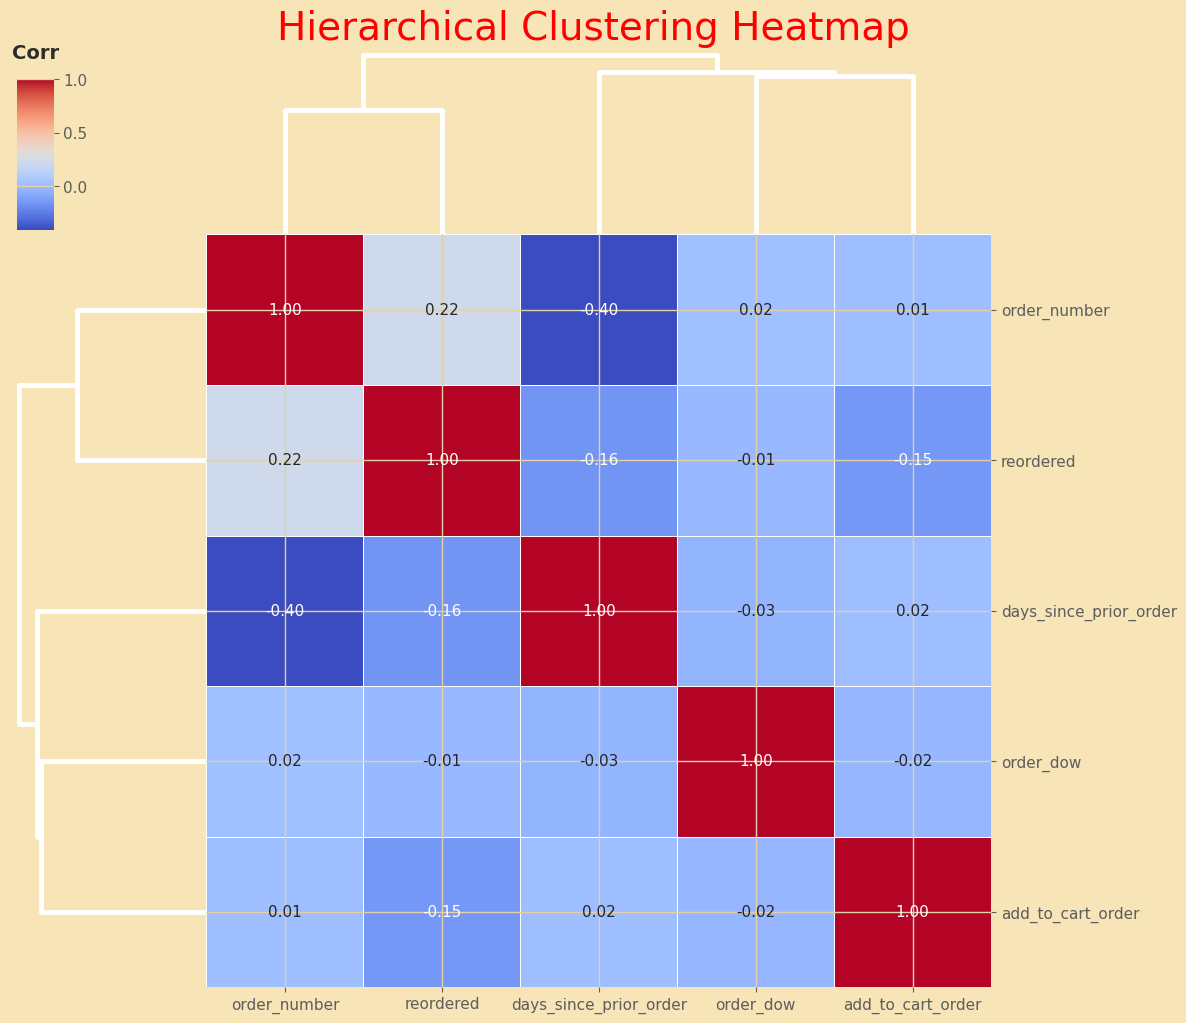

In [11]:
Corelation = TrainData.select_dtypes(include=['number']).corr()
g = sns.clustermap(
    Corelation,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    figsize=(12, 10),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(3.5)
        line.set_color('white')
g.fig.suptitle('Hierarchical Clustering Heatmap', fontsize=28, color='red', y=1.02)
g.ax_cbar.set_title('Corr', fontsize=14)
plt.show()

In [12]:
def Interactive_Correlation(Data : pd.DataFrame,
                            method : str ='pearson'):
    """
    Generates an interactive correlation heatmap.
    Arguments:
        Data: The DataFrame to analyze (e.g., TrainData).
        method: 'pearson', 'spearman', or 'kendall'.
    """
    Corrs = Data.select_dtypes(include=['number']).corr(method=method)
    fig = px.imshow(Corrs,
                    text_auto=".2f",
                    aspect="auto",
                    color_continuous_scale='RdBu_r',
                    zmin=-1,
                    zmax=1,
                    title=f"Interactive Correlation Matrix ({method.capitalize()})",
                    labels=dict(color="Correlation"),
                   )
    fig.update_layout(width=800,
                      height=800,
                      xaxis_nticks=36,
                      template='plotly_dark',
                      title_font_size=28,
                      title_font_color='red',
                     )
    return fig.show()

In [13]:
Interactive_Correlation(TrainData, method='pearson')

`days_since_prior_order` vs `order_number` have biggest value of correlation. It is 0.4, seems there is a related. The longer a user will order again, has a relationship with the size of orders placed in the future. It also impact with `reordered` criteria.

In [14]:
# Spearman method will meeasure monotonic relationship (Rank-based)
# BEST for 'add_to_cart_order' and 'order_number'
Interactive_Correlation(TrainData, method='spearman')

# Univariate Analysis

In [15]:
def Identify_Columns(Data):
    numerical_cols = Data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print("Numerical columns:", numerical_cols)
    return numerical_cols

def Univariate_Statistics(Data, col):
    iqr = Data[col].quantile(0.75) - Data[col].quantile(0.25)
    stats_dict = {
        'count': [Data[col].count()],
        'mean': [Data[col].mean()],
        'median': [Data[col].median()],
        'std': [Data[col].std()],
        'min': [Data[col].min()],
        'max': [Data[col].max()],
        'q25': [Data[col].quantile(0.25)],
        'q75': [Data[col].quantile(0.75)],
        'iqr': [iqr],
        'upper_whisker': [Data[col].quantile(0.75) + 1.5 * iqr],
        'lower_whisker': [Data[col].quantile(0.25) - 1.5 * iqr],
        'skewness': [stats.skew(Data[col].dropna())],
        'kurtosis': [stats.kurtosis(Data[col].dropna())],
        'missing': [Data[col].isnull().sum()],
    }
    return pd.DataFrame(stats_dict)

In [16]:
Numerics = Identify_Columns(TrainData)
all_stats = list()
for col in Numerics:
    stats_df = Univariate_Statistics(TrainData, col)
    stats_df.index = [col]
    all_stats.append(stats_df)

StatSum = pd.concat(all_stats)
display(StatSum)

Numerical columns: ['order_number', 'order_dow', 'days_since_prior_order', 'add_to_cart_order', 'reordered']


,count,mean,median,std,min,max,q25,q75,iqr,upper_whisker,lower_whisker,skewness,kurtosis,missing
order_number,1384617,17.09,11.00,16.61,4.00,100.00,6.00,21.00,15.00,43.50,-16.50,2.24,5.90,0
order_dow,1384617,2.70,3.00,2.17,0.00,6.00,1.00,5.00,4.00,11.00,-5.00,0.18,-1.40,0
days_since_prior_order,1384617,17.07,15.00,10.43,0.00,30.00,7.00,30.00,23.00,64.50,-27.50,0.07,-1.57,0
add_to_cart_order,1384617,8.76,7.00,7.42,1.00,80.00,3.00,12.00,9.00,25.50,-10.50,1.69,4.17,0
reordered,1384617,0.60,1.00,0.49,0.00,1.00,0.00,1.00,1.00,2.50,-1.50,-0.40,-1.84,0


In [17]:
def Visualized_Univariate(Data:pd.DataFrame,
                          NumCols:list,
                          save:bool=False,
                         ):
    n_cols = len(NumCols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(15, 4 * n_cols))
    axes = axes.ravel()

    for i, col in enumerate(NumCols):
        # Histogram
        axes[i*2].hist(Data[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[i*2].set_title(f'Histogram - {col}')
        axes[i*2].set_xlabel(col)
        axes[i*2].set_ylabel('Frequency')

        # Boxplot
        axes[i*2+1].boxplot(Data[col].dropna())
        axes[i*2+1].set_title(f'Boxplot - {col}')
        axes[i*2+1].set_ylabel(col)

    plt.tight_layout()
    if save:
        plt.savefig('univariate_analysis_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Individual KDE plots for continuous variables
    print('\n\n')
    continuous_cols = ['days_since_prior_order', 'order_number', 'add_to_cart_order']
    for col in continuous_cols:
        if col in NumCols:
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            sns.histplot(Data[col], kde=True, bins=30)
            plt.title(f'Distribution - {col}')

            plt.subplot(1, 2, 2)
            sns.boxplot(y=Data[col])
            plt.title(f'Boxplot - {col}')

            plt.tight_layout()
            if save:
                plt.savefig(f'univariate_{col}.png', dpi=300, bbox_inches='tight')
            plt.show()
    return True

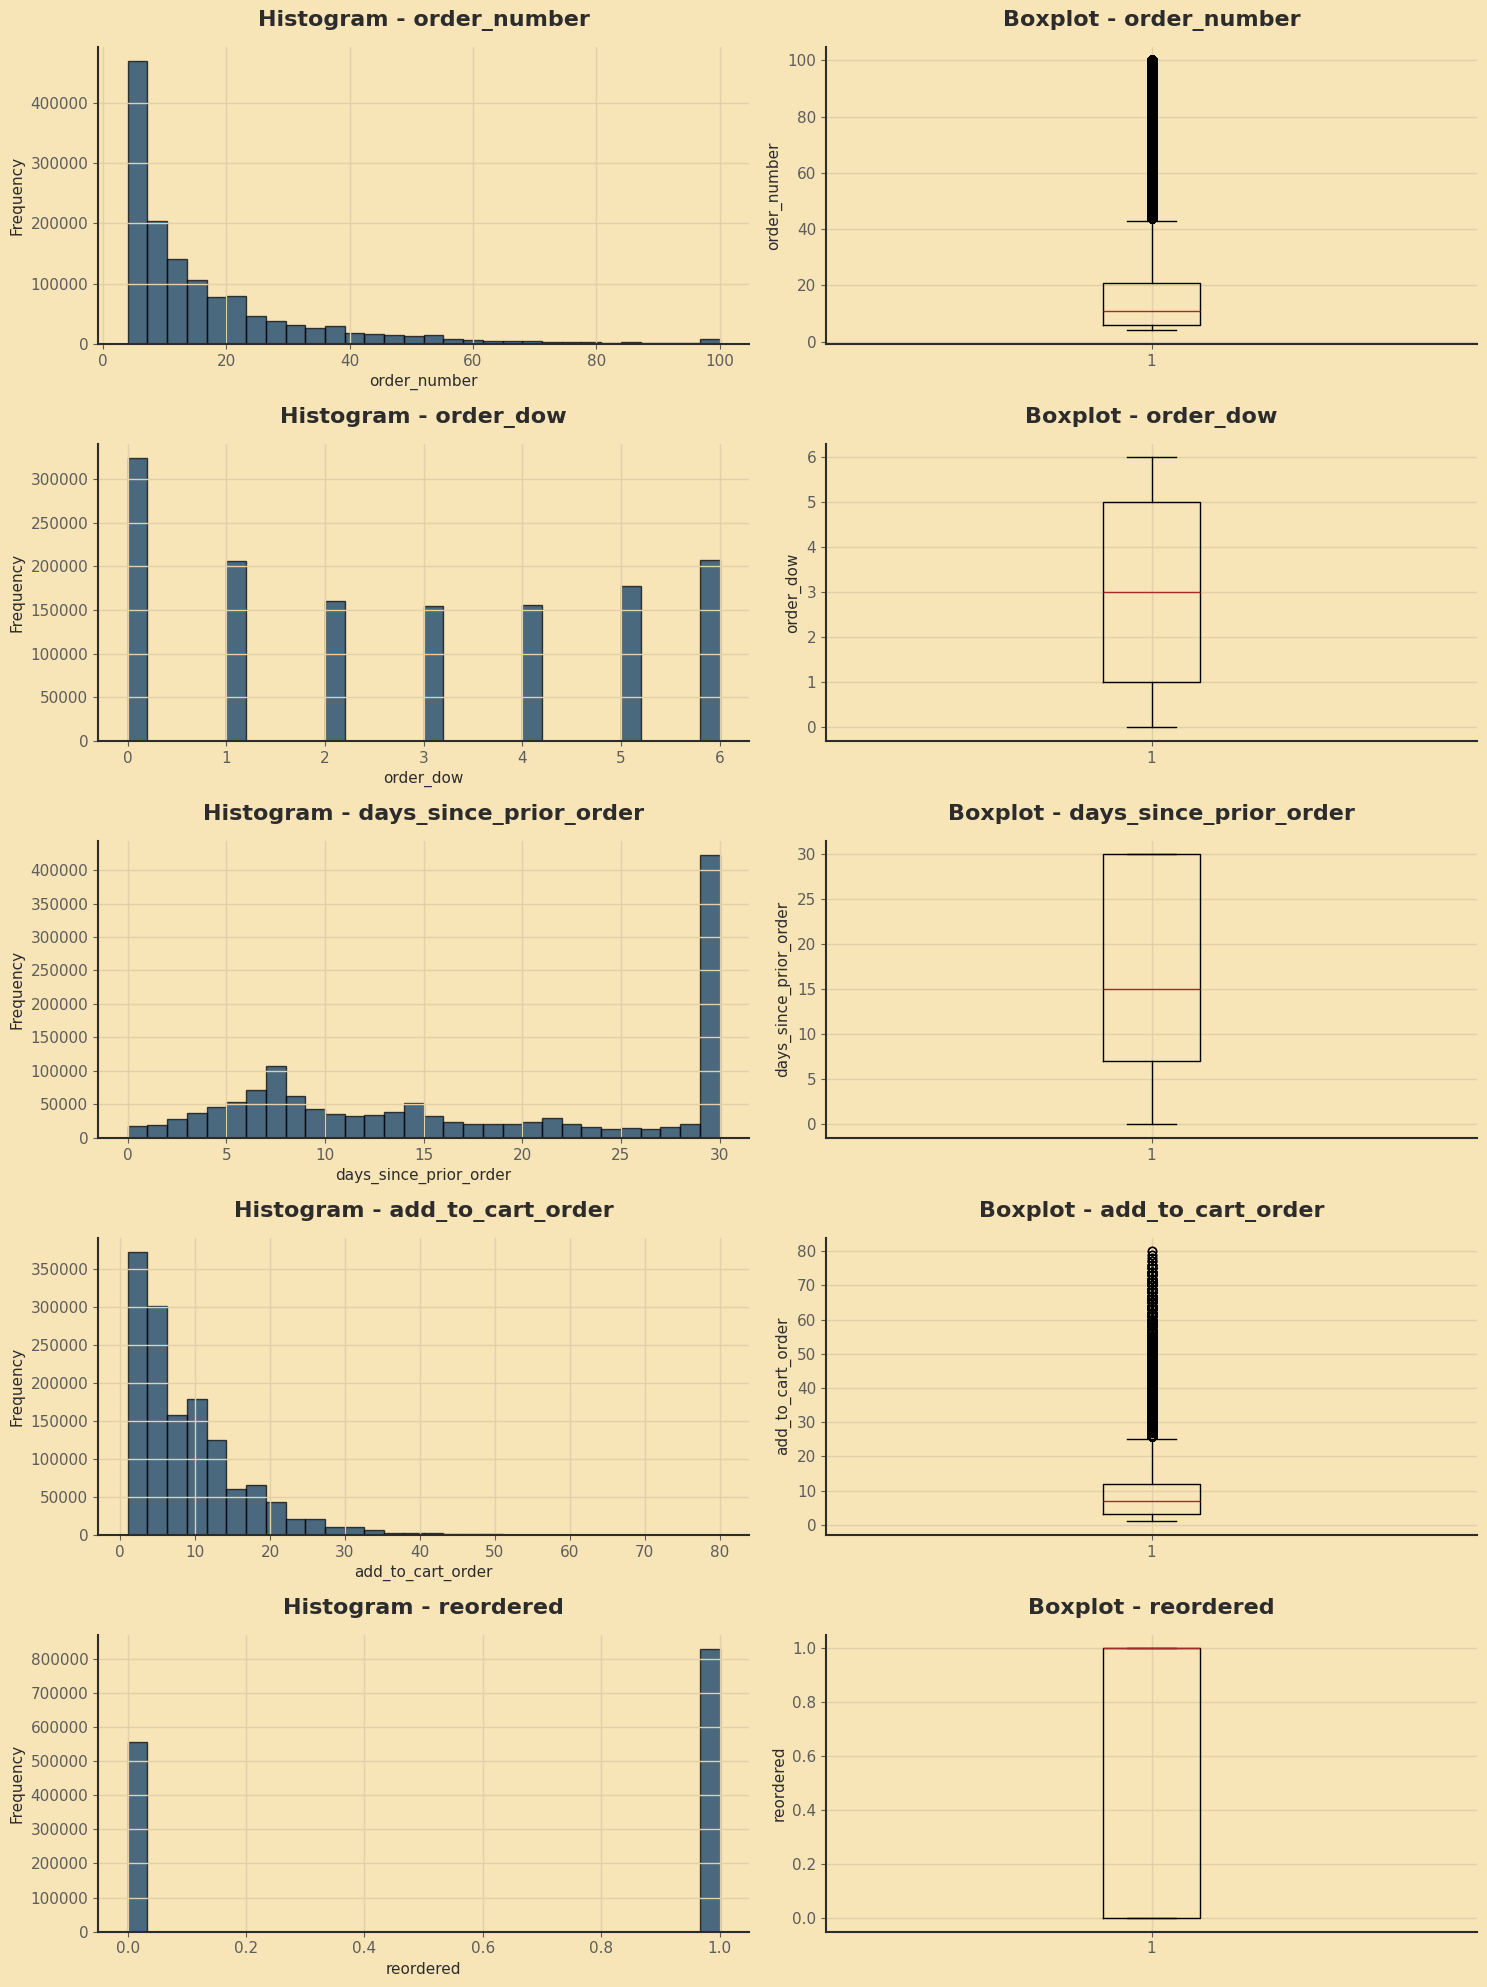

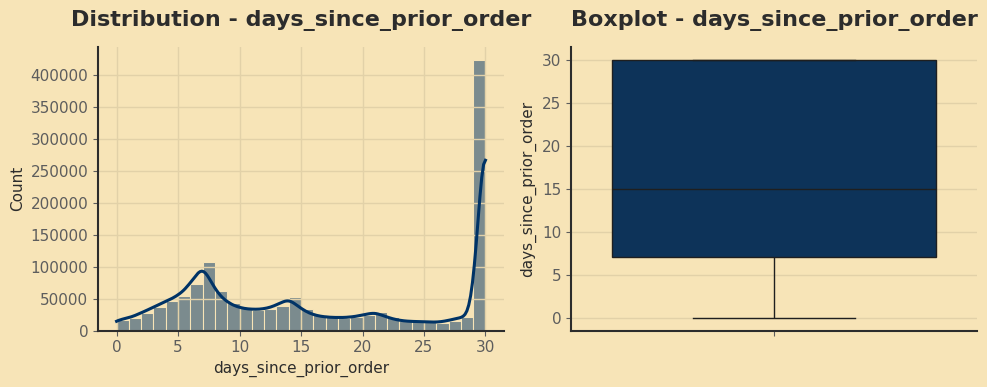

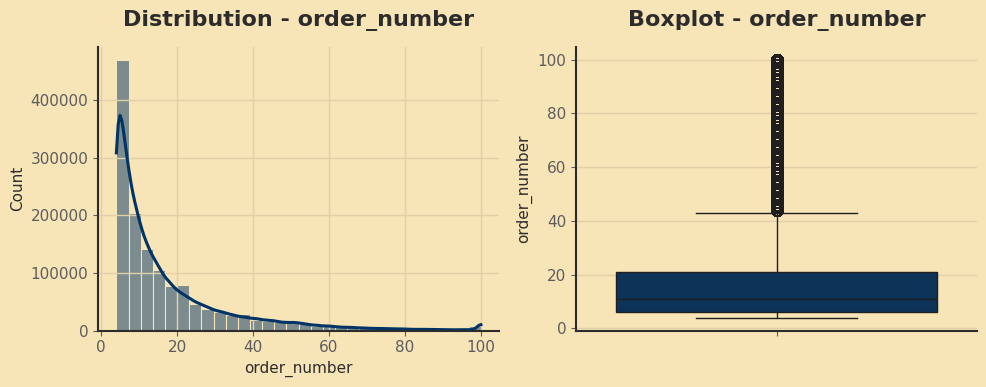

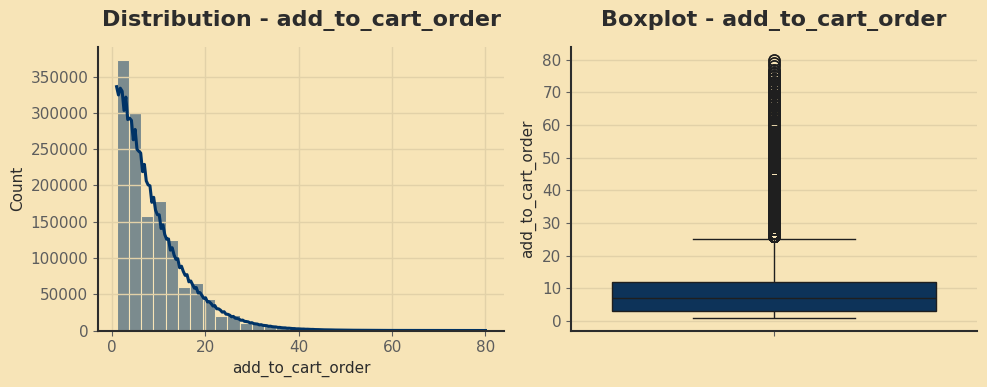

True

In [18]:
Visualized_Univariate(TrainData, Numerics, False)

`days_since_prior_order` appears as censored data, meaning that data older than 30 days is considered to be 30 days only, no more. For `order_number` column, InstaCart data does not contain data that does not have an `order_number` at all. This means that this data is only for customers who have made purchases.

# Fitting Probability Distribution

Fitting a probability distribution to data captures the underlying pattern of variability, enabling accurate modeling and inference. This process is essential for reliable predictions, hypothesis testing, and simulations in data science tasks like time series forecasting or health data analysis.

## Key Reasons
there are 3 keys in order to try fitting probability distribution.
- First is about **Accurate Predictions**. It's mean about a well-fitted distribution reflects the data's true behavior, improving forecasts in models like Prophet or GARCH, where assuming normality on non-normal data leads to biased results.
- **Statistical Inference** that supports valid hypothesis tests, confidence intervals, and p-values; mismatched distributions inflate Type I/II errors.
- **Process Understanding** to reveals data generation mechanisms, such as skewness in clinical malnutrition metrics, guiding causal inference or SHAP interpretability.

## Practical Benefits
Maximum likelihood estimation maximizes the probability of observing your data, outperforming least squares for complex shapes like exponentials or gammas. In ML pipelines, it normalizes inputs for CNNs/LSTMs, enhances anomaly detection, and avoids overfitting by constraining flexible models. Visual checks like Q-Q plots and goodness-of-fit tests (e.g., Kolmogorov-Smirnov) confirm the fit before deployment.

In [19]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from dataclasses import dataclass
from typing import Tuple, List, Optional
import warnings

warnings.filterwarnings('ignore')


@dataclass
class FitResult:
    """Store results of distribution fitting"""
    name: str
    score: float
    params: tuple
    dist_type: str  # 'continuous' or 'discrete'
    sse: float = None
    aic: float = None
    bic: float = None


class DistributionFitter:
    """Efficient probability distribution fitter with multiple goodness-of-fit tests"""

    # Common continuous distributions (faster fitting)
    COMMON_CONTINUOUS = [
        'norm', 'lognorm', 'expon', 'gamma', 'beta', 'weibull_min',
        'weibull_max', 'uniform', 'chi2', 'pareto', 'rayleigh',
        'logistic', 'gumbel_r', 'cauchy', 't'
    ]

    # Common discrete distributions
    COMMON_DISCRETE = [
        'poisson', 'binom', 'nbinom', 'geom', 'bernoulli', 'randint'
    ]

    # All scipy continuous distributions
    ALL_CONTINUOUS = [
        'alpha', 'anglit', 'arcsine', 'beta', 'betaprime', 'bradford',
        'burr', 'cauchy', 'chi', 'chi2', 'cosine', 'dgamma', 'dweibull',
        'erlang', 'expon', 'exponweib', 'exponpow', 'f', 'fatiguelife',
        'fisk', 'foldcauchy', 'foldnorm', 'frechet_r', 'frechet_l',
        'genlogistic', 'genpareto', 'genexpon', 'genextreme', 'gamma',
        'gengamma', 'genhalflogistic', 'gilbrat', 'gompertz', 'gumbel_r',
        'gumbel_l', 'halfcauchy', 'halflogistic', 'halfnorm', 'hypsecant',
        'invgamma', 'invgauss', 'invweibull', 'johnsonsb', 'johnsonsu',
        'laplace', 'logistic', 'loggamma', 'loglaplace', 'lognorm', 'lomax',
        'maxwell', 'mielke', 'moyal', 'nakagami', 'ncx2', 'ncf', 'nct',
        'norm', 'pareto', 'pearson3', 'powerlaw', 'powerlognorm', 'powernorm',
        'rdist', 'reciprocal', 'rayleigh', 'rice', 'recipinvgauss',
        'semicircular', 't', 'triang', 'truncexpon', 'truncnorm',
        'tukeylambda', 'uniform', 'vonmises', 'wald', 'weibull_min',
        'weibull_max', 'wrapcauchy'
    ]

    # All scipy discrete distributions
    ALL_DISCRETE = [
        'bernoulli', 'binom', 'boltzmann', 'dlaplace', 'geom',
        'logser', 'nbinom', 'planck', 'poisson',
        'randint', 'skellam', 'yulesimon', 'zipf', 'zipfian'
    ]

    def __init__(self, data: np.ndarray, dist_type: str = 'auto', use_all_distributions: bool = False):
        """
        Initialize fitter with data

        Parameters:
        -----------
        data : array-like
            Data to fit distributions to
        dist_type : str
            'continuous', 'discrete', or 'auto' (auto-detect)
        use_all_distributions : bool
            If True, test all distributions. If False, test only common ones (faster)
        """
        self.data = np.asarray(data)

        # Auto-detect distribution type
        if dist_type == 'auto':
            # Check if data contains only integers
            if np.all(self.data == self.data.astype(int)):
                self.dist_type = 'discrete'
            else:
                self.dist_type = 'continuous'
        else:
            self.dist_type = dist_type

        # Select appropriate distributions
        if self.dist_type == 'continuous':
            self.distributions = self.ALL_CONTINUOUS if use_all_distributions else self.COMMON_CONTINUOUS
        elif self.dist_type == 'discrete':
            self.distributions = self.ALL_DISCRETE if use_all_distributions else self.COMMON_DISCRETE
        else:
            # Test both
            if use_all_distributions:
                self.distributions = self.ALL_CONTINUOUS + self.ALL_DISCRETE
            else:
                self.distributions = self.COMMON_CONTINUOUS + self.COMMON_DISCRETE

        self._histogram = None
        self._bin_edges = None
        self._bin_centers = None
        self._unique_values = None
        self._value_counts = None

    def _compute_histogram(self):
        """Compute histogram once and cache it"""
        if self._histogram is None:
            bins = np.histogram_bin_edges(self.data, bins='fd')
            self._histogram, self._bin_edges = np.histogram(self.data, bins=bins, density=True)
            self._bin_centers = (self._bin_edges[:-1] + self._bin_edges[1:]) / 2
        return self._histogram, self._bin_centers

    def _compute_discrete_pmf(self):
        """Compute probability mass function for discrete data"""
        if self._unique_values is None:
            unique, counts = np.unique(self.data.astype(int), return_counts=True)
            self._unique_values = unique
            self._value_counts = counts / len(self.data)  # Normalize to probabilities
        return self._unique_values, self._value_counts

    @staticmethod
    def _is_discrete_dist(dist_name: str) -> bool:
        """Check if distribution is discrete"""
        discrete_dists = [
            'bernoulli', 'binom', 'boltzmann', 'dlaplace', 'geom',
            'hypergeom', 'logser', 'nbinom', 'nchypergeom_fisher',
            'nchypergeom_wallenius', 'nhypergeom', 'planck', 'poisson',
            'randint', 'skellam', 'yulesimon', 'zipf', 'zipfian'
        ]
        return dist_name in discrete_dists

    @staticmethod
    def _fit_single_distribution(dist_name: str, data: np.ndarray,
                                 hist: np.ndarray, bin_centers: np.ndarray,
                                 unique_vals: np.ndarray = None,
                                 value_counts: np.ndarray = None,
                                 return_error: bool = False) -> Optional[FitResult]:
        """
        Fit a single distribution (designed for parallel execution)

        Returns None if fitting fails, or tuple (None, error_msg) if return_error=True
        """
        try:
            dist = getattr(st, dist_name)
            is_discrete = DistributionFitter._is_discrete_dist(dist_name)

            # Fit distribution with appropriate data
            if is_discrete:
                # For discrete distributions, use integer data
                int_data = data.astype(int)

                # Get data range for validation
                data_min, data_max = int_data.min(), int_data.max()

                # Special handling for different discrete distributions
                if dist_name == 'binom':
                    # Binomial: needs n >= max(data)
                    n = int(data_max)
                    if n <= 0 or n > 10000:  # Reasonable bounds
                        return (None, f"binom: n={n} out of reasonable range") if return_error else None
                    # Estimate p from data
                    p_init = np.mean(int_data) / n if n > 0 else 0.5
                    p_init = np.clip(p_init, 0.01, 0.99)
                    params = (n, p_init, 0)  # n, p, loc

                elif dist_name == 'nbinom':
                    # Negative binomial: estimate parameters from mean and variance
                    mean_val = np.mean(int_data)
                    var_val = np.var(int_data)
                    if var_val <= mean_val:
                        return (None, "nbinom: variance <= mean (use Poisson instead)") if return_error else None
                    # Method of moments
                    n_est = mean_val ** 2 / (var_val - mean_val)
                    p_est = mean_val / var_val
                    if n_est <= 0 or p_est <= 0 or p_est >= 1:
                        return (None, f"nbinom: invalid params n={n_est:.2f}, p={p_est:.2f}") if return_error else None
                    params = (n_est, p_est, 0)

                elif dist_name == 'geom':
                    # Geometric: estimate p from mean
                    mean_val = np.mean(int_data)
                    if mean_val <= 0:
                        return (None, "geom: mean <= 0") if return_error else None
                    p_est = 1.0 / (mean_val + 1)
                    p_est = np.clip(p_est, 0.001, 0.999)
                    params = (p_est, 0)

                elif dist_name == 'poisson':
                    # Poisson: lambda = mean
                    mu = np.mean(int_data)
                    if mu <= 0:
                        return (None, "poisson: mean <= 0") if return_error else None
                    params = (mu, 0)

                elif dist_name == 'bernoulli':
                    # Bernoulli: only for binary data (0,1)
                    if not np.all(np.isin(int_data, [0, 1])):
                        return (None, "bernoulli: data not binary (0,1)") if return_error else None
                    p_est = np.mean(int_data)
                    params = (p_est, 0)

                elif dist_name == 'randint':
                    # Discrete uniform: randint(low, high)
                    low, high = data_min, data_max + 1
                    params = (low, high)

                else:
                    # Try generic fitting for other distributions
                    try:
                        params = dist.fit(int_data)
                    except:
                        return (None, f"{dist_name}: fit() failed") if return_error else None
            else:
                # Continuous distribution
                params = dist.fit(data)

            # Separate parameters based on distribution type
            if is_discrete:
                # Discrete distributions have different parameter structures
                if dist_name == 'poisson':
                    arg = params[:-1]  # (mu,)
                    loc = params[-1]
                    scale = 1
                elif dist_name == 'binom':
                    arg = params[:-1]  # (n, p)
                    loc = params[-1] if len(params) > 2 else 0
                    scale = 1
                elif dist_name == 'nbinom':
                    arg = params[:-1]  # (n, p)
                    loc = params[-1] if len(params) > 2 else 0
                    scale = 1
                elif dist_name == 'geom':
                    arg = params[:-1]  # (p,)
                    loc = params[-1] if len(params) > 1 else 0
                    scale = 1
                elif dist_name == 'bernoulli':
                    arg = params[:-1]  # (p,)
                    loc = params[-1] if len(params) > 1 else 0
                    scale = 1
                elif dist_name == 'randint':
                    arg = params  # (low, high)
                    loc = 0
                    scale = 1
                else:
                    arg = params[:-2] if len(params) > 2 else params[:-1]
                    loc = params[-2] if len(params) > 2 else 0
                    scale = params[-1] if len(params) > 1 else 1
            else:
                arg = params[:-2]
                loc = params[-2]
                scale = params[-1]

            # Calculate probability values and SSE
            if is_discrete:
                # Use PMF for discrete distributions
                if unique_vals is not None:
                    if dist_name == 'randint':
                        pmf = dist.pmf(unique_vals, *arg)
                    else:
                        pmf = dist.pmf(unique_vals, *arg, loc=loc)

                    # Check for invalid values
                    if np.any(np.isnan(pmf)) or np.any(np.isinf(pmf)):
                        return (None, f"{dist_name}: invalid PMF values") if return_error else None

                    # Calculate SSE
                    sse = np.sum((value_counts - pmf) ** 2)
                else:
                    return (None, f"{dist_name}: no unique values provided") if return_error else None

                # Calculate log-likelihood
                if dist_name == 'randint':
                    loglik = np.sum(dist.logpmf(data.astype(int), *arg))
                else:
                    loglik = np.sum(dist.logpmf(data.astype(int), *arg, loc=loc))
            else:
                # Use PDF for continuous distributions
                pdf = dist.pdf(bin_centers, loc=loc, scale=scale, *arg)

                # Check for invalid PDF values
                if np.any(np.isnan(pdf)) or np.any(np.isinf(pdf)):
                    return (None, f"{dist_name}: invalid PDF values") if return_error else None

                # Calculate SSE
                sse = np.sum((hist - pdf) ** 2)

                # Calculate log-likelihood
                loglik = np.sum(dist.logpdf(data, *params))

            # Check log-likelihood
            if np.isnan(loglik) or np.isinf(loglik):
                return (None, f"{dist_name}: invalid log-likelihood") if return_error else None

            k = len(params)
            n = len(data)
            aic = 2 * k - 2 * loglik
            bic = k * np.log(n) - 2 * loglik

            return FitResult(
                name=dist_name,
                score=sse,
                params=params,
                dist_type='discrete' if is_discrete else 'continuous',
                sse=sse,
                aic=aic,
                bic=bic
            )

        except Exception as e:
            error_msg = f"{dist_name}: {str(e)}"
            return (None, error_msg) if return_error else None

    def fit(self, method: str = 'sse', n_jobs: int = -1, verbose: bool = True) -> FitResult:
        """
        Fit distributions using specified method

        Parameters:
        -----------
        method : str
            Goodness-of-fit method: 'sse', 'aic', 'bic', 'ks'
        n_jobs : int
            Number of parallel jobs (-1 uses all CPUs)
        verbose : bool
            Print progress and results

        Returns:
        --------
        FitResult with best distribution
        """
        # Print data diagnostics
        if verbose:
            print(f"\nData diagnostics:")
            print(f"  Shape: {self.data.shape}")
            print(f"  Range: [{self.data.min():.2f}, {self.data.max():.2f}]")
            print(f"  Mean: {self.data.mean():.2f}, Std: {self.data.std():.2f}")
            print(f"  Unique values: {len(np.unique(self.data))}")
            if self.dist_type == 'discrete':
                print(f"  Value range: {self.data.min()} to {self.data.max()}")

        # Prepare data based on type
        if self.dist_type == 'continuous' or self.dist_type == 'auto':
            hist, bin_centers = self._compute_histogram()
            unique_vals, value_counts = None, None

        if self.dist_type == 'discrete' or self.dist_type == 'auto':
            unique_vals, value_counts = self._compute_discrete_pmf()
            if self.dist_type == 'continuous':
                unique_vals, value_counts = None, None
            else:
                hist, bin_centers = self._compute_histogram()

        # Determine number of workers
        if n_jobs == -1:
            import multiprocessing
            n_jobs = multiprocessing.cpu_count()

        results = []
        errors = []

        if verbose:
            dist_type_str = self.dist_type if self.dist_type != 'auto' else 'continuous & discrete'
            print(f"\nFitting {len(self.distributions)} {dist_type_str} distributions using {method.upper()} method...")
            print(f"Using {n_jobs} parallel workers\n")

        # Parallel fitting
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            # Submit all jobs
            futures = {
                executor.submit(self._fit_single_distribution, dist_name,
                              self.data, hist, bin_centers, unique_vals, value_counts,
                              return_error=verbose): dist_name
                for dist_name in self.distributions
            }

            # Collect results as they complete
            completed = 0
            for future in as_completed(futures):
                completed += 1
                if verbose and completed % 5 == 0:
                    print(f"Progress: {completed}/{len(self.distributions)} distributions tested")

                result = future.result()

                if verbose and isinstance(result, tuple):
                    # Error case with message
                    _, error_msg = result
                    errors.append(error_msg)
                elif result is not None:
                    results.append(result)

        # Print errors if verbose
        if verbose and errors:
            print(f"\nFailed distributions ({len(errors)}):")
            for error in errors[:10]:  # Show first 10 errors
                print(f"  - {error}")
            if len(errors) > 10:
                print(f"  ... and {len(errors) - 10} more")

        if not results:
            error_summary = "\n".join(errors[:5])
            raise RuntimeError(
                f"No distributions could be successfully fit to the data.\n"
                f"Data range: [{self.data.min()}, {self.data.max()}]\n"
                f"Sample errors:\n{error_summary}\n\n"
                f"Suggestions:\n"
                f"  1. Check if your data has reasonable values\n"
                f"  2. Try dist_type='continuous' if data has decimals\n"
                f"  3. Ensure data is not all the same value\n"
                f"  4. For count data starting at 1, try: data - data.min() to shift to 0"
            )

        if verbose:
            print(f"\nSuccessfully fit {len(results)} distributions\n")

        # Select best distribution based on method
        if method == 'sse':
            best = min(results, key=lambda x: x.sse)
            best.score = best.sse
        elif method == 'aic':
            best = min(results, key=lambda x: x.aic)
            best.score = best.aic
        elif method == 'bic':
            best = min(results, key=lambda x: x.bic)
            best.score = best.bic
        elif method == 'ks':
            # Kolmogorov-Smirnov test
            ks_results = []
            for res in results:
                try:
                    dist = getattr(st, res.name)
                    if res.dist_type == 'discrete':
                        # KS test doesn't work well for discrete, skip
                        continue
                    _, p_value = st.kstest(self.data, res.name, args=res.params)
                    res.score = p_value
                    ks_results.append(res)
                except:
                    pass
            if ks_results:
                best = max(ks_results, key=lambda x: x.score)
            else:
                raise RuntimeError("KS test failed for all distributions")
        else:
            raise ValueError(f"Unknown method: {method}. Use 'sse', 'aic', 'bic', or 'ks'")

        if verbose:
            print(f"\n{'='*70}")
            print(f"Best Distribution: {best.name} ({best.dist_type})")
            print(f"{method.upper()} Score: {best.score:.6f}")
            print(f"Parameters: {best.params}")
            if best.aic:
                print(f"AIC: {best.aic:.2f}, BIC: {best.bic:.2f}, SSE: {best.sse:.6f}")
            print(f"{'='*70}\n")

        return best

    def get_top_distributions(self, method: str = 'sse', n: int = 5,
                            n_jobs: int = -1) -> pd.DataFrame:
        """
        Get top N best-fitting distributions

        Returns DataFrame sorted by goodness of fit
        """
        # Prepare data based on type
        if self.dist_type == 'continuous' or self.dist_type == 'auto':
            hist, bin_centers = self._compute_histogram()
            unique_vals, value_counts = None, None

        if self.dist_type == 'discrete' or self.dist_type == 'auto':
            unique_vals, value_counts = self._compute_discrete_pmf()
            if self.dist_type == 'continuous':
                unique_vals, value_counts = None, None
            else:
                hist, bin_centers = self._compute_histogram()

        if n_jobs == -1:
            import multiprocessing
            n_jobs = multiprocessing.cpu_count()

        results = []

        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            futures = {
                executor.submit(self._fit_single_distribution, dist_name,
                              self.data, hist, bin_centers, unique_vals, value_counts): dist_name
                for dist_name in self.distributions
            }

            for future in as_completed(futures):
                result = future.result()
                if result is not None:
                    results.append(result)

        # Create DataFrame
        df = pd.DataFrame([
            {
                'Distribution': r.name,
                'Type': r.dist_type,
                'SSE': r.sse,
                'AIC': r.aic,
                'BIC': r.bic,
                'Parameters': str(r.params)
            }
            for r in results
        ])

        # Sort by specified method
        sort_col = method.upper()
        ascending = method != 'ks'  # KS wants highest p-value
        df = df.sort_values(sort_col, ascending=ascending).reset_index(drop=True)

        return df.head(n)

    def plot_best_fit(self, best: FitResult, bins: int = 50, figsize: Tuple[int, int] = (10, 6)):
        """Plot histogram with best-fit distribution overlay"""
        plt.figure(figsize=figsize)

        dist = getattr(st, best.name)

        if best.dist_type == 'discrete':
            # For discrete distributions, parse parameters correctly
            if best.name == 'poisson':
                arg = best.params[:-1]  # (mu,)
                loc = best.params[-1]
            elif best.name == 'binom':
                arg = best.params[:-1]  # (n, p)
                loc = best.params[-1] if len(best.params) > 2 else 0
            elif best.name == 'nbinom':
                arg = best.params[:-1]  # (n, p)
                loc = best.params[-1] if len(best.params) > 2 else 0
            elif best.name == 'geom':
                arg = best.params[:-1]  # (p,)
                loc = best.params[-1] if len(best.params) > 1 else 0
            elif best.name == 'bernoulli':
                arg = best.params[:-1]  # (p,)
                loc = best.params[-1] if len(best.params) > 1 else 0
            elif best.name == 'randint':
                arg = best.params  # (low, high)
                loc = 0
            else:
                arg = best.params[:-2] if len(best.params) > 2 else best.params[:-1]
                loc = best.params[-2] if len(best.params) > 2 else 0

            # Get observed frequencies
            unique_vals, value_counts = self._compute_discrete_pmf()

            # Plot observed frequencies
            plt.bar(unique_vals, value_counts, alpha=0.7, color='skyblue',
                   edgecolor='black', label='Observed', width=0.8)

            # Plot fitted PMF
            x_range = np.arange(unique_vals.min(), unique_vals.max() + 1)

            # Calculate PMF without scale parameter for discrete distributions
            if best.name == 'randint':
                pmf = dist.pmf(x_range, *arg)
            else:
                pmf = dist.pmf(x_range, *arg, loc=loc)

            plt.plot(x_range, pmf, 'ro-', linewidth=2, markersize=6,
                    label=f'{best.name} (SSE={best.sse:.6f})')

            plt.xlabel('Value', fontsize=12)
            plt.ylabel('Probability', fontsize=12)
            plt.title(f'Best Fit Distribution: {best.name} (Discrete)',
                     fontsize=14, fontweight='bold')
        else:
            # For continuous distributions
            arg = best.params[:-2]
            loc = best.params[-2]
            scale = best.params[-1]

            # Use histogram
            plt.hist(self.data, bins=bins, density=True, alpha=0.7,
                    color='skyblue', edgecolor='black', label='Data')

            # Plot fitted PDF
            x = np.linspace(self.data.min(), self.data.max(), 1000)
            y = dist.pdf(x, loc=loc, scale=scale, *arg)

            plt.plot(x, y, 'r-', linewidth=2, label=f'{best.name} (SSE={best.sse:.6f})')

            plt.xlabel('Value', fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.title(f'Best Fit Distribution: {best.name} (Continuous)',
                     fontsize=14, fontweight='bold')

        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [20]:
# Convenience function for quick fitting
def fit_distribution(data, method='sse', dist_type='auto', use_all_distributions=False,
                     plot=True, n_jobs=-1, verbose=True):
    """
    Quick function to fit best distribution to data

    Parameters:
    -----------
    data : array-like
        Data to fit
    method : str
        Fitting method ('sse', 'aic', 'bic', 'ks')
    dist_type : str
        'continuous', 'discrete', or 'auto' (auto-detect from data)
    use_all_distributions : bool
        Test all distributions (slower) or just common ones
    plot : bool
        Show plot of best fit
    n_jobs : int
        Number of parallel workers
    verbose : bool
        Print results

    Returns:
    --------
    FitResult object with best distribution
    """
    fitter = DistributionFitter(data, dist_type=dist_type,
                                use_all_distributions=use_all_distributions)
    best = fitter.fit(method=method, n_jobs=n_jobs, verbose=verbose)

    if plot:
        fitter.plot_best_fit(best)

    return best


In [21]:
TrainData.columns

Index(['order_id', 'user_id', 'product_id', 'aisle_id', 'department_id',
       'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered'],
      dtype='object')


Data diagnostics:
  Shape: (1384617,)
  Range: [4.00, 100.00]
  Mean: 17.09, Std: 16.61
  Unique values: 97

Fitting 15 continuous distributions using AIC method...
Using 2 parallel workers

Progress: 5/15 distributions tested
Progress: 10/15 distributions tested
Progress: 15/15 distributions tested

Successfully fit 15 distributions


Best Distribution: gamma (continuous)
AIC Score: 3898208.446470
Parameters: (np.float64(0.375006537339313), np.float64(3.999999999999999), np.float64(24.621910530888684))
AIC: 3898208.45, BIC: 3898244.87, SSE: 0.403326



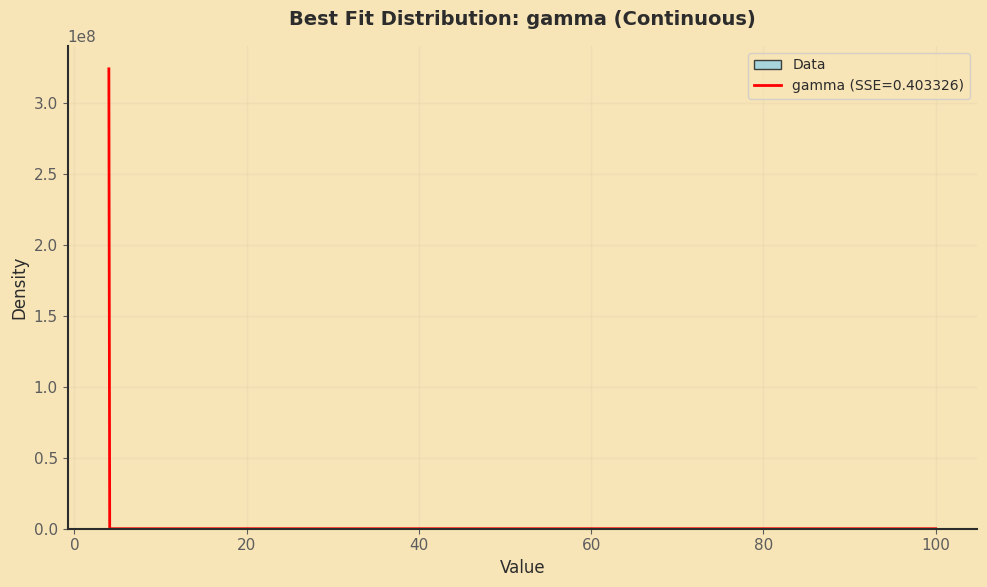

In [22]:
DataFit = TrainData['order_number']
best_cont = fit_distribution(DataFit, method='aic', dist_type='continuous')


Data diagnostics:
  Shape: (1384617,)
  Range: [4.00, 100.00]
  Mean: 17.09, Std: 16.61
  Unique values: 97
  Value range: 4 to 100

Fitting 14 discrete distributions using AIC method...
Using 2 parallel workers

Progress: 5/14 distributions tested
Progress: 10/14 distributions tested

Failed distributions (9):
  - bernoulli: data not binary (0,1)
  - boltzmann: fit() failed
  - dlaplace: fit() failed
  - logser: fit() failed
  - planck: fit() failed
  - skellam: fit() failed
  - yulesimon: fit() failed
  - zipf: fit() failed
  - zipfian: fit() failed

Successfully fit 5 distributions


Best Distribution: geom (discrete)
AIC Score: 10551934.226590
Parameters: (np.float64(0.05527485108189432), 0)
AIC: 10551934.23, BIC: 10551958.51, SSE: 0.008596



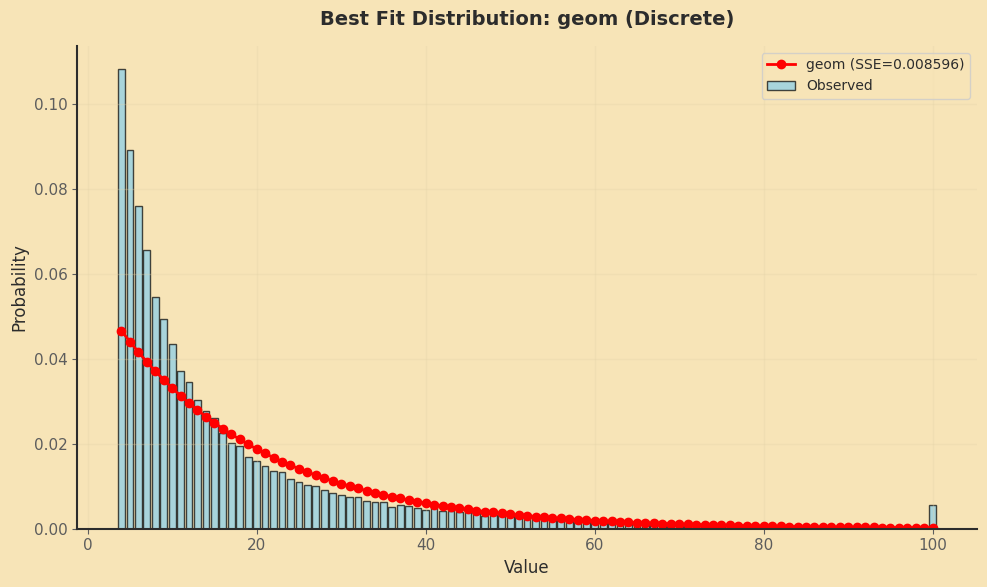

In [23]:
best_disc = fit_distribution(DataFit, method='aic', dist_type='discrete', use_all_distributions = True)


Data diagnostics:
  Shape: (1384617,)
  Range: [4.00, 100.00]
  Mean: 17.09, Std: 16.61
  Unique values: 97
  Value range: 4 to 100

Fitting 6 discrete distributions using BIC method...
Using 2 parallel workers

Progress: 5/6 distributions tested

Failed distributions (1):
  - bernoulli: data not binary (0,1)

Successfully fit 5 distributions


Best Distribution: geom (discrete)
BIC Score: 10551958.508458
Parameters: (np.float64(0.05527485108189432), 0)
AIC: 10551934.23, BIC: 10551958.51, SSE: 0.008596



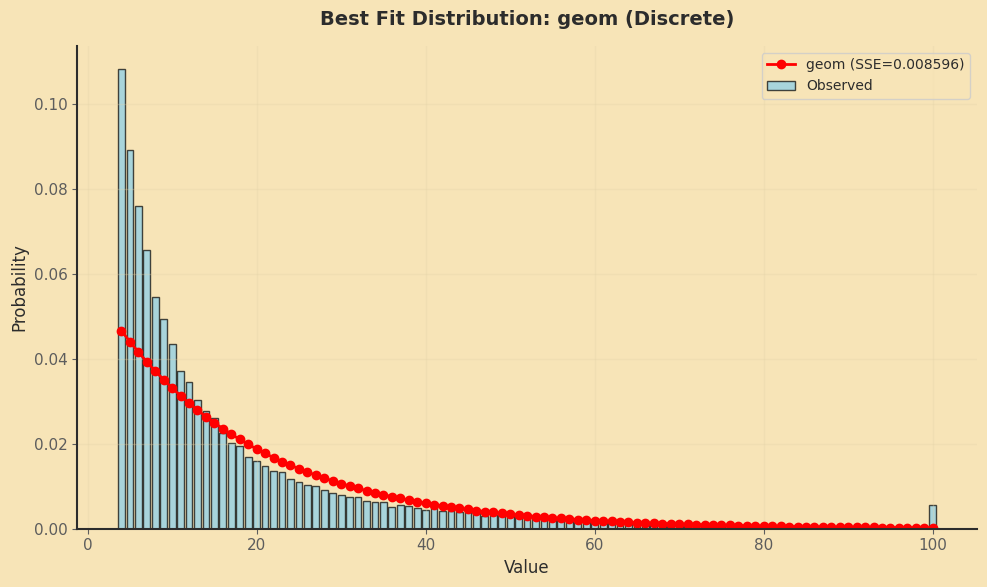

In [24]:
best_auto = fit_distribution(DataFit, method='bic', dist_type='auto')

In [25]:
#Get top 5 distributions for discrete data
print("\n" + "="*70)
print("TOP 5 DISTRIBUTIONS FOR DISCRETE DATA")
print("="*70)
fitter = DistributionFitter(DataFit, dist_type='discrete',
                            use_all_distributions=True)
fitter.fit(verbose=False)
print("\nTop 5 Best-Fitting Distributions:")
print(fitter.get_top_distributions(method='aic', n=5))


TOP 5 DISTRIBUTIONS FOR DISCRETE DATA

Top 5 Best-Fitting Distributions:
  Distribution      Type  SSE           AIC           BIC  \
0         geom  discrete 0.01 10,551,934.23 10,551,958.51   
1       nbinom  discrete 0.01 10,642,109.98 10,642,146.40   
2      randint  discrete 0.04 12,668,449.18 12,668,473.46   
3      poisson  discrete 0.07 22,933,252.00 22,933,276.28   
4        binom  discrete 0.08 28,658,978.90 28,659,015.33   

                                          Parameters  
0               (np.float64(0.05527485108189432), 0)  
1  (np.float64(1.1281470280470605), np.float64(0....  
2                       (np.int64(4), np.int64(101))  
3                (np.float64(17.091410115577087), 0)  
4          (100, np.float64(0.17091410115577088), 0)  


# Bivariate Analysis

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def perform_bivariate_analysis(df):
    # sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = (12, 10)

    fig, axes = plt.subplots(2, 2)
    plt.subplots_adjust(hspace=0.4)

    # 1. Order Hour vs Reorder Rate
    # Fix: Added observed=False to groupby to silence the warning
    hour_reorder = df.groupby('order_hour_of_day', observed=False)['reordered'].mean().reset_index()
    sns.lineplot(data=hour_reorder, x='order_hour_of_day', y='reordered',
                 marker='o', ax=axes[0, 0], color='teal')
    axes[0, 0].set_title('Reorder Rate by Hour of Day')
    axes[0, 0].set_ylabel('Reorder Probability')

    # 2. Add to Cart Order vs Reordered
    # Fix: Assigned 'x' to 'hue' and set legend=False to satisfy new Seaborn requirements
    cart_reorder = df[df['add_to_cart_order'] <= 20].groupby('add_to_cart_order', observed=False)['reordered'].mean().reset_index()
    sns.barplot(data=cart_reorder, x='add_to_cart_order', y='reordered',
                hue='add_to_cart_order', palette='viridis', legend=False, ax=axes[0, 1])
    axes[0, 1].set_title('Reorder Rate by Add-to-Cart Position')

    # 3. Days Since Prior Order vs Reorder Rate
    # Fix: Added observed=False
    days_reorder = df.groupby('days_since_prior_order', observed=False)['reordered'].mean().reset_index()
    sns.lineplot(data=days_reorder, x='days_since_prior_order', y='reordered',
                 ax=axes[1, 0], color='coral')
    axes[1, 0].set_title('Reorder Rate by Days Since Prior Order')

    # 4. Day of Week vs Order Size (Density)
    # Fix: Added observed=False and mapped x to hue for the boxplot
    basket_data = df.groupby('order_id', observed=False).agg({'reordered':'count', 'order_dow':'first'})
    sns.boxplot(data=basket_data, x='order_dow', y='reordered',
                hue='order_dow', palette='Set2', legend=False, ax=axes[1, 1])
    axes[1, 1].set_title('Basket Size Distribution by Day of Week')
    axes[1, 1].set_ylabel('Items per Order')

    plt.tight_layout()
    plt.show()

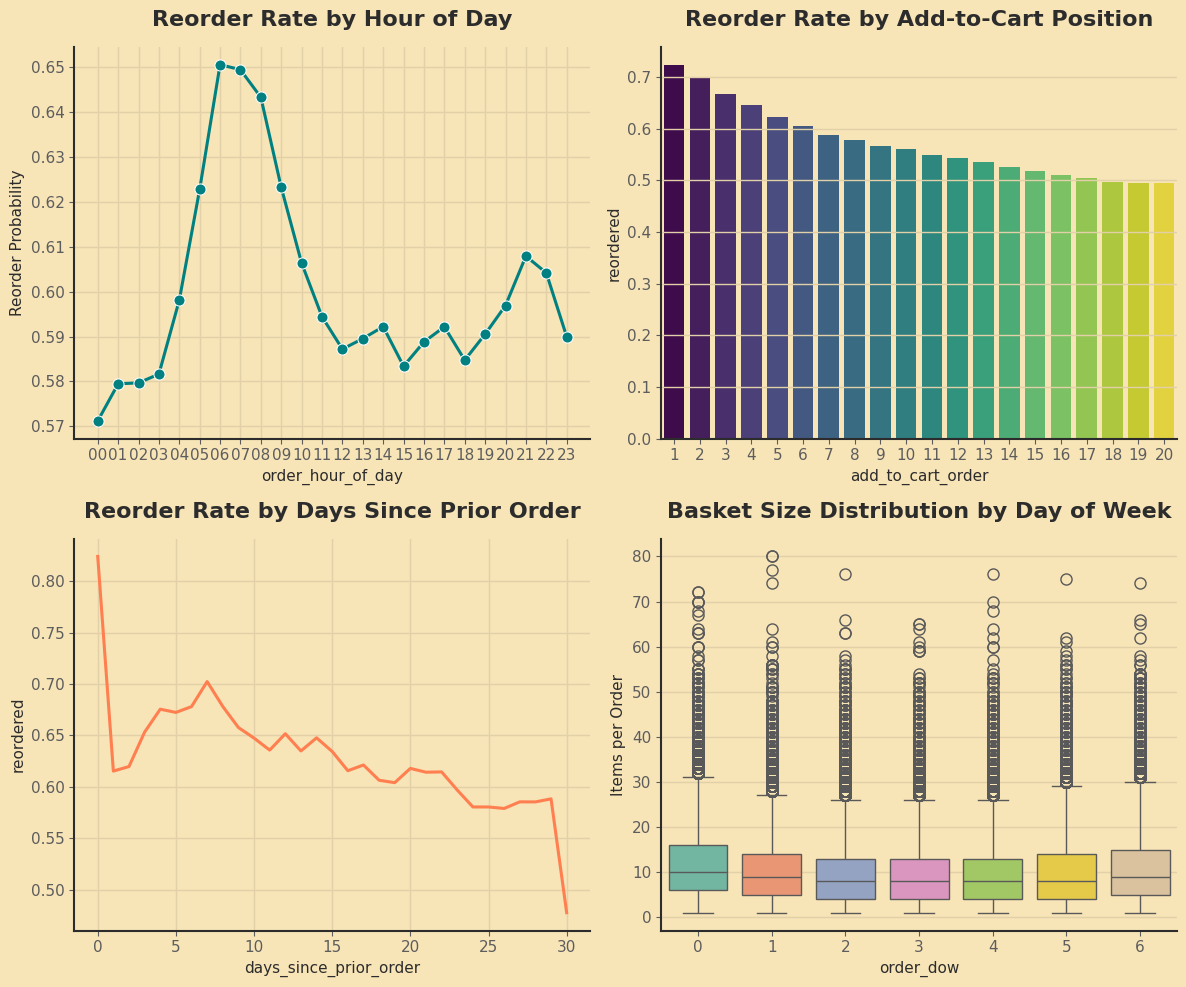

In [ ]:
perform_bivariate_analysis(TrainData)

### Analysis Ideas for Recommendation Modeling

| Analysis | Purpose |
| --- | --- |
| **Order Hour vs. Reorder Rate** | Does the time of day affect the likelihood of someone reordering a product? |
| **Days Since Prior vs. Reorder Rate** | Does a long gap between orders lead to more or fewer reorders? |
| **Add to Cart Order vs. Reordered** | Are items added to the cart first more likely to be reordered? (Crucial for ranking) |
| **Department vs. Reorder Rate** | Which categories have the most "loyal" customers? |

### Advanced Analysis Ideas
To move beyond basic bar and line charts, advanced bivariate analysis for recommendation systems focuses on **conditional probabilities**, **user-product intersections**, and **lagged behavior**.

* **Reorder Heatmap (Timing):** Intersection of `order_dow` and `order_hour_of_day` to find "Peak Habit" zones.
* **Aisle Loyalty vs. Basket Size:** Do users who shop in certain aisles (e.g., Produce vs. Snacks) tend to have larger total orders?
* **Probability of Reorder by Cumulative Purchase:** How does the probability of reordering a product change the 1st time vs. the 10th time it's bought?

### Feature Engineering Insights for your Model

Based on this analysis, you should create these features for your recommendation model:

1. **User-Product Frequency:** How many times `user_id` bought `product_id` / total orders by `user_id`.
2. **Aisle Reorder Rate:** Is the user shopping in high-reorder aisles (like Milk/Eggs) or low-reorder aisles (like Spices)?
3. **The "Morning Rush" Binary:** A flag for orders between 6 AM and 10 AM, as reorder behavior often shifts during breakfast hours.
4. **Cart-Relative Position:** `add_to_cart_order / total_items_in_basket`. This normalizes the "urgency" of an item across different basket sizes.

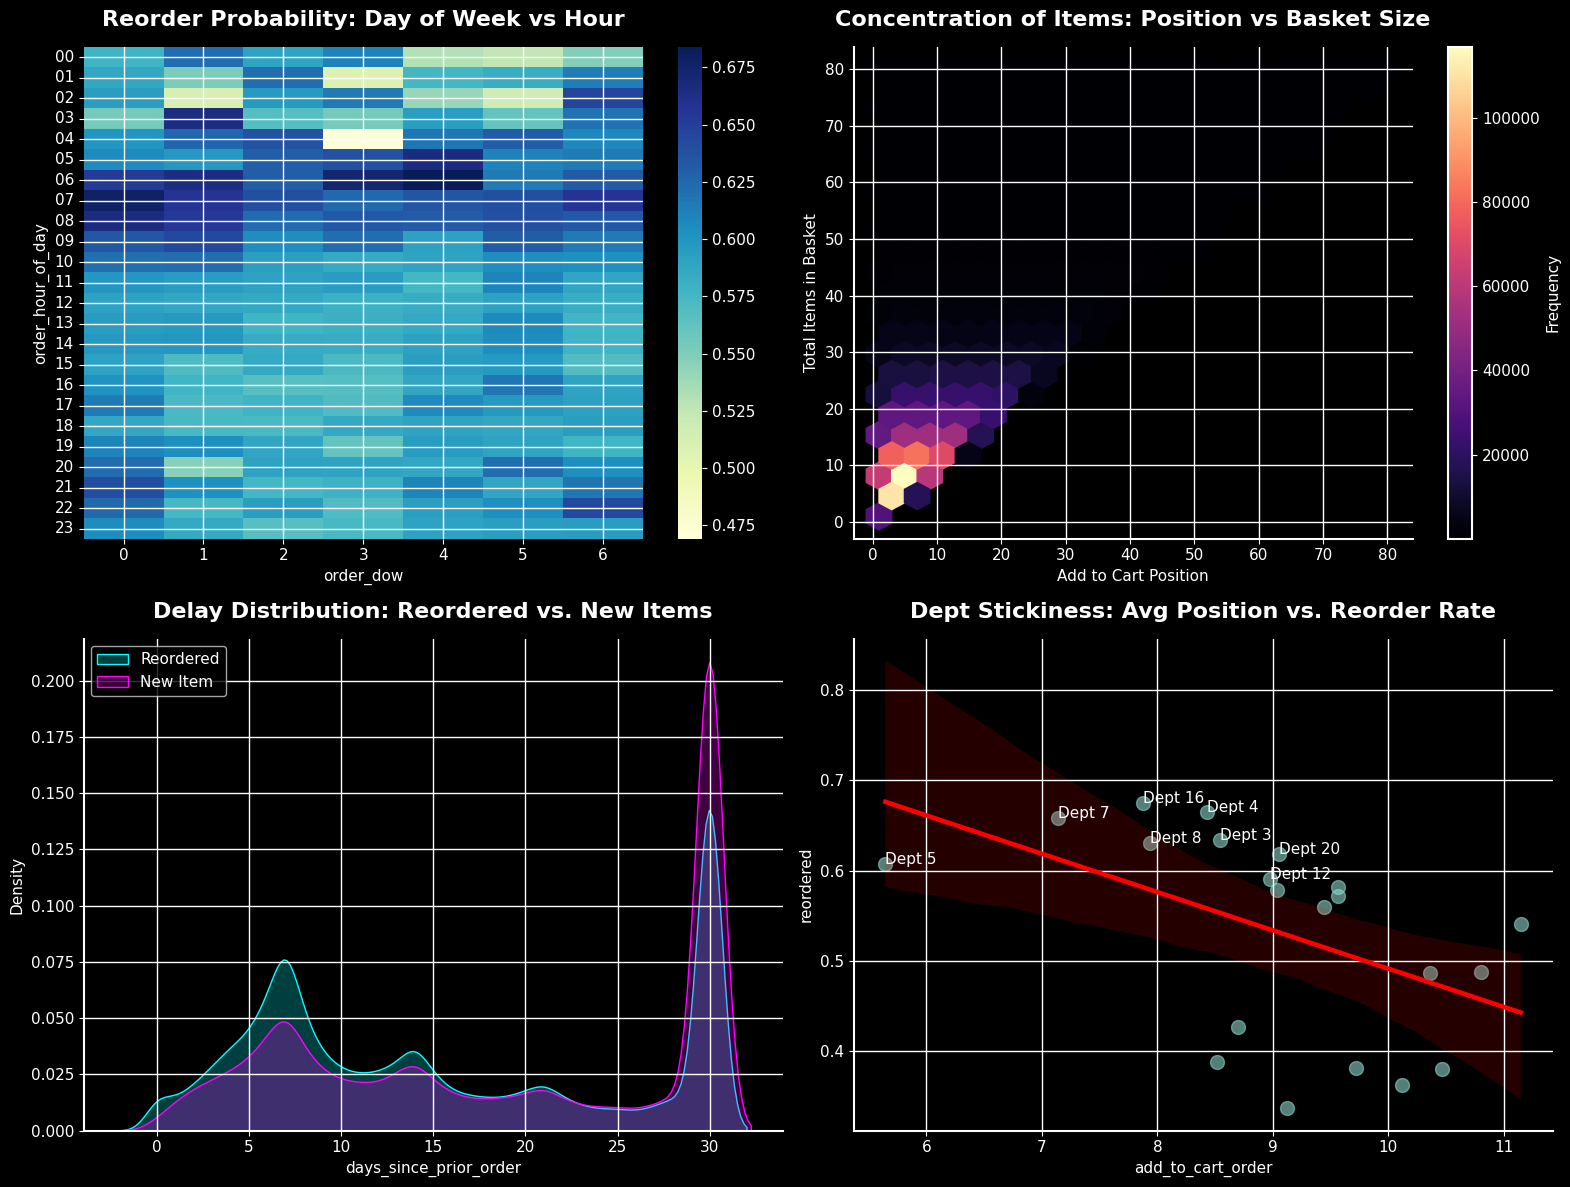

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def perform_advanced_bivariate(df):
    plt.style.use('dark_background') # Looks great in VS Code / WSL
    fig = plt.figure(figsize=(16, 12))

    # 1. TIME-BASED REORDER DENSITY (Heatmap)
    # Finding the "Golden Hours" for reordering
    plt.subplot(2, 2, 1)
    pivot_reorder = df.pivot_table(index='order_hour_of_day',
                                  columns='order_dow',
                                  values='reordered',
                                  aggfunc='mean')
    sns.heatmap(pivot_reorder, cmap='YlGnBu', annot=False)
    plt.title('Reorder Probability: Day of Week vs Hour')

    # 2. JOINT DISTRIBUTION: Add-to-cart vs. Order Size
    # Do people who buy MANY items add reordered items later or earlier?
    plt.subplot(2, 2, 2)
    # First, calculate basket size per order
    basket_sizes = df.groupby('order_id').size().reset_index(name='basket_size')
    temp_df = df.merge(basket_sizes, on='order_id')

    plt.hexbin(temp_df['add_to_cart_order'], temp_df['basket_size'],
               gridsize=20, cmap='magma', mincnt=1)
    plt.colorbar(label='Frequency')
    plt.xlabel('Add to Cart Position')
    plt.ylabel('Total Items in Basket')
    plt.title('Concentration of Items: Position vs Basket Size')

    # 3. KERNEL DENSITY ESTIMATE (KDE): Days Since Prior Order
    # Compare the distribution of time-gaps for Reordered vs New items
    plt.subplot(2, 2, 3)
    sns.kdeplot(data=df[df['reordered'] == 1], x='days_since_prior_order',
                label='Reordered', fill=True, color='cyan')
    sns.kdeplot(data=df[df['reordered'] == 0], x='days_since_prior_order',
                label='New Item', fill=True, color='magenta')
    plt.title('Delay Distribution: Reordered vs. New Items')
    plt.legend()

    # 4. DEPARTMENT STICKINESS (Scatter with Marginal Distributions)
    # X = Average Add to cart position, Y = Reorder Rate
    plt.subplot(2, 2, 4)
    dept_stats = df.groupby('department_id').agg({
        'reordered': 'mean',
        'add_to_cart_order': 'mean'
    }).reset_index()

    sns.regplot(data=dept_stats, x='add_to_cart_order', y='reordered',
                scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
    # Annotate top 5 stickiest departments
    for i, txt in enumerate(dept_stats['department_id']):
        if dept_stats['reordered'][i] > dept_stats['reordered'].mean() + 0.05:
            plt.annotate(f"Dept {txt}", (dept_stats['add_to_cart_order'][i], dept_stats['reordered'][i]))

    plt.title('Dept Stickiness: Avg Position vs. Reorder Rate')

    plt.tight_layout()
    plt.show()

perform_advanced_bivariate(TrainData)

Instead of just looking at raw averages (like "reorder rate"), we treat the reorder rate as a **probability distribution** with uncertainty. This is especially powerful for recommendation models because it prevents us from overestimating the importance of a product that was bought only once and reordered once (100% rate, but low confidence) versus a product bought 100 times and reordered 60 times (60% rate, but high confidence).

### The Bayesian Approach: Beta-Binomial Model
We will model the relationship between a categorical feature (like `department_id` or `order_dow`) and the target `reordered` using a **Beta-Binomial conjugate prior**.
* **Prior:** What we know about reorder rates across the whole dataset.
* **Likelihood:** The actual data observed for a specific category.
* **Posterior:** Our updated belief about that category's reorder probability.

When you run this code, you are looking at **Credible Intervals**:
1. **Peak Position (x-axis):** This is the most likely reorder rate for that category.
2. **Width of the Curve:** This represents **uncertainty**.
* A **tall, narrow curve** means we have lots of data and are very sure about that reorder rate.
* A **short, wide curve** means we have little data and the "true" reorder rate could vary significantly.

3. **Distance from Prior:** If a curve is far to the right of the dashed black line, that category is a significantly stronger driver for reorders than the average item.

### Applying this to your Recommendation Model

From a Bayesian perspective, you shouldn't just feed the raw `reorder_rate` into your model. Instead, you should use the **Posterior Mean** (calculated in the code as `mean_post`). **Why?** Because the Posterior Mean acts as a "shrinkage" estimator. If a product has very few orders, the Bayesian mean will "shrink" toward the global average, preventing the model from overreacting to small sample sizes.

### Advanced Concept: Interaction of Two Variables (e.g., Time + Day)
If you want to see how two variables interact (like `order_dow` and `order_hour_of_day`) using Bayesian logic, you can calculate the **Expected Value** for each combination. This heatmap is "safer" than a standard mean heatmap because it automatically dampens noise in hours/days where there are very few orders (like 3 AM on a Tuesday).

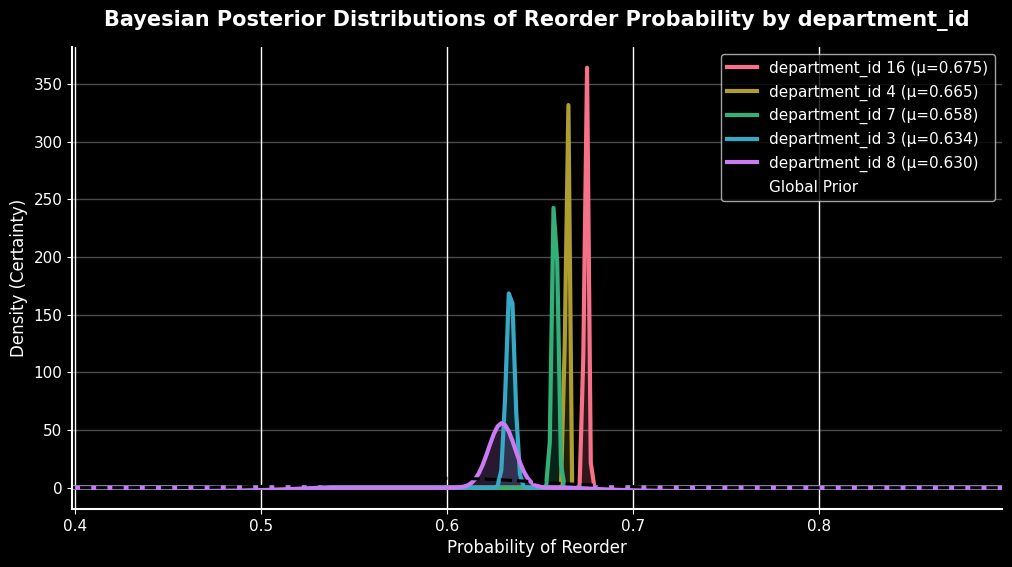

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta

def bayesian_bivariate_analysis(df, categorical_col, target_col='reordered'):
    """
    Performs Bayesian inference to compare reorder probabilities across categories.
    """
    plt.style.use('seaborn-v0_8-muted')

    # 1. Calculate Global Prior (Alpha and Beta for the whole dataset)
    # These represent our "starting" belief
    global_mean = df[target_col].mean()
    # Strength of prior (pseudo-observations) - can be adjusted
    prior_strength = 100
    alpha_prior = global_mean * prior_strength
    beta_prior = (1 - global_mean) * prior_strength

    # 2. Calculate Posterior for each category
    stats = df.groupby(categorical_col)[target_col].agg(['count', 'sum'])
    stats['alpha_post'] = alpha_prior + stats['sum']
    stats['beta_post'] = beta_prior + (stats['count'] - stats['sum'])
    stats['mean_post'] = stats['alpha_post'] / (stats['alpha_post'] + stats['beta_post'])

    # Sort by highest posterior mean and take top 5 for visualization clarity
    top_stats = stats.sort_values('mean_post', ascending=False).head(5)

    # 3. Visualization
    plt.figure(figsize=(12, 6))
    x = np.linspace(0, 1, 500)

    colors = sns.color_palette("husl", len(top_stats))

    for i, (idx, row) in enumerate(top_stats.iterrows()):
        y = beta.pdf(x, row['alpha_post'], row['beta_post'])
        plt.plot(x, y, label=f'{categorical_col} {idx} (μ={row["mean_post"]:.3f})', color=colors[i], lw=3)
        plt.fill_between(x, 0, y, alpha=0.2, color=colors[i])

    # Plot the Global Prior for comparison
    y_prior = beta.pdf(x, alpha_prior, beta_prior)
    plt.plot(x, y_prior, label='Global Prior', color='black', linestyle='--')

    plt.title(f'Bayesian Posterior Distributions of Reorder Probability by {categorical_col}', fontsize=15)
    plt.xlabel('Probability of Reorder', fontsize=12)
    plt.ylabel('Density (Certainty)', fontsize=12)
    plt.xlim(global_mean - 0.2, global_mean + 0.3) # Zoom in on relevant range
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Example Usage:
bayesian_bivariate_analysis(TrainData, 'department_id')

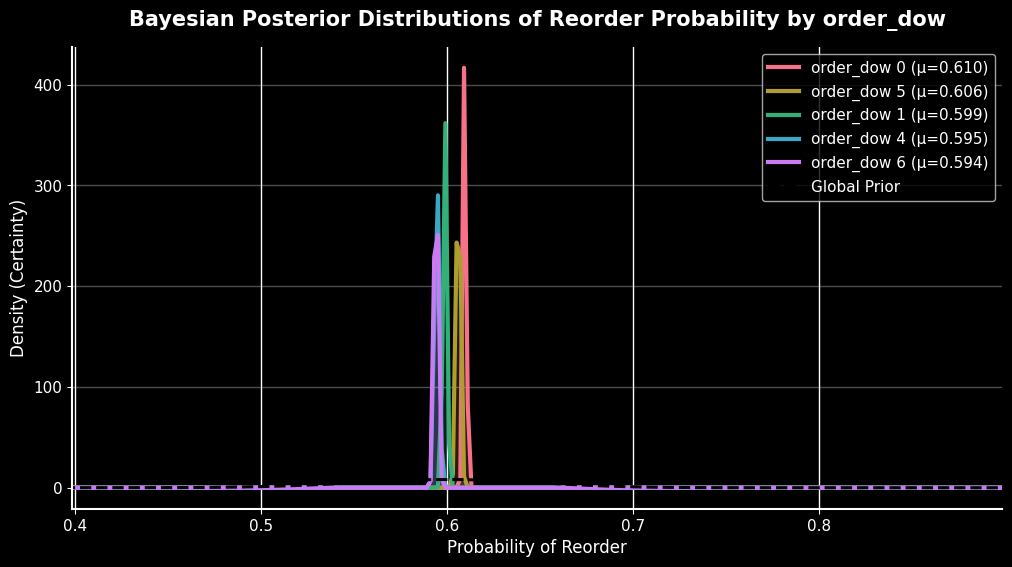

In [ ]:
bayesian_bivariate_analysis(TrainData, 'order_dow')

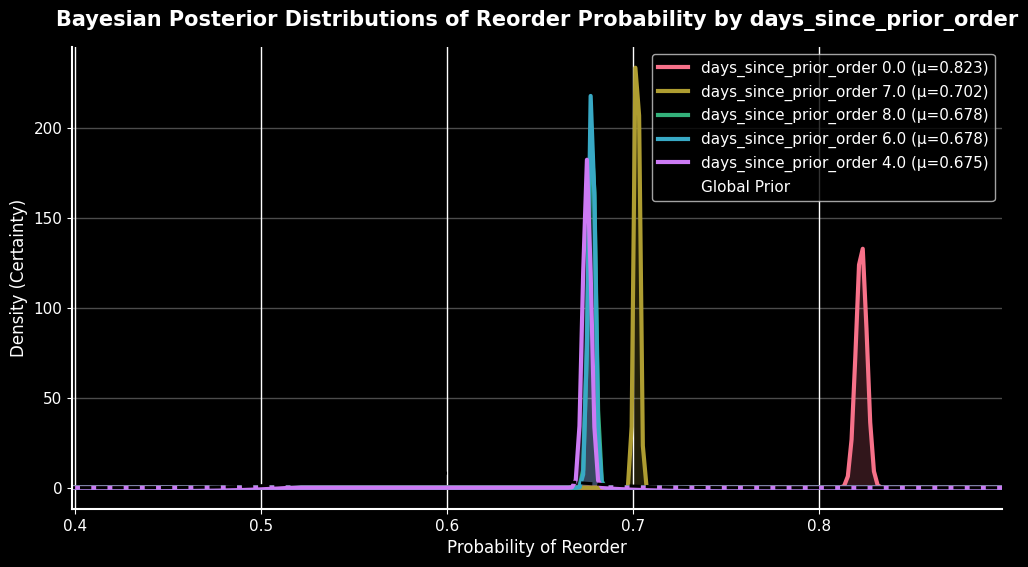

In [ ]:
bayesian_bivariate_analysis(TrainData, 'days_since_prior_order')

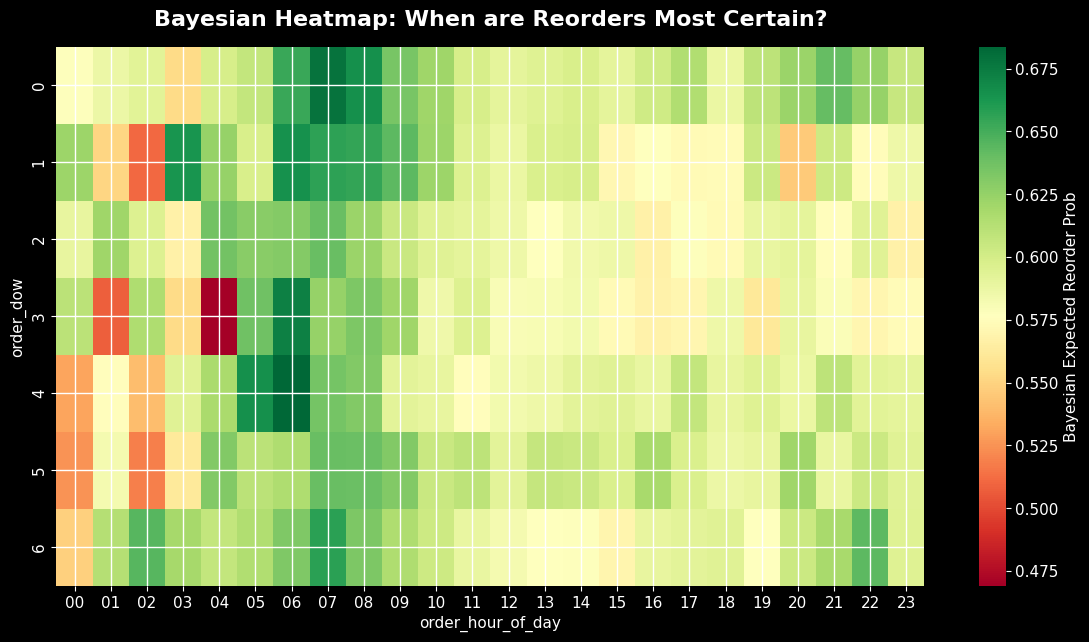

In [ ]:
def bayesian_heatmap(df):
    # Calculate alpha/beta per cell
    pivot = df.groupby(['order_dow', 'order_hour_of_day'])['reordered'].agg(['sum', 'count'])

    # Bayesian Smoothing (Laplace smoothing is a simple Bayesian prior)
    # Expected Value = (successes + 1) / (total + 2)
    pivot['exp_value'] = (pivot['sum'] + 1) / (pivot['count'] + 2)

    heatmap_data = pivot['exp_value'].unstack()

    plt.figure(figsize=(14, 7))
    sns.heatmap(heatmap_data, cmap='RdYlGn', annot=False, cbar_kws={'label': 'Bayesian Expected Reorder Prob'})
    plt.title('Bayesian Heatmap: When are Reorders Most Certain?')
    plt.show()

bayesian_heatmap(TrainData)

To implement a **Hierarchical Bayesian Model (HBM)** for personalized recommendations, we transition from looking at "average users" to looking at "specific users" while still sharing information across the entire population. In a recommendation context, this means we assume every user has their own unique behavior (e.g., some are morning shoppers, some are evening shoppers), but these behaviors all come from a common "global" distribution. This is known as **Partial Pooling**.

### 1. The Hierarchical Model Structure
We will model the reorder probability for a specific user () at a specific hour () as:
Where:
* : Are the **Individual Effects** (User-level).
* : Are the **Global Means** (Population-level).
* The model "shrinks" extreme individual behaviors toward the global mean if the user has very few orders.

---

### 2. Python Implementation: Hierarchical MCMC

Because Hierarchical models have a high number of dimensions, I have optimized this sampler to handle a subset of users. In a production environment on **Ubuntu 24.04**, you would typically use `PyMC` or `Stan` for this, but here is the logic implemented using `numpy` for transparency.

## CPU Version

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.special import expit  # Efficient sigmoid
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')


class EfficientHierarchicalBayesian:
    """
    Optimized Hierarchical Bayesian Model with:
    - Parallel user-level updates using joblib
    - Vectorized operations
    - Adaptive MCMC proposal distributions
    - Mini-batch sampling for large datasets
    """

    def __init__(self, n_jobs=-1, use_minibatch=True, batch_size=1000):
        """
        Parameters:
        -----------
        n_jobs : int
            Number of parallel jobs (-1 = all CPUs)
        use_minibatch : bool
            Use mini-batch sampling for large datasets
        batch_size : int
            Size of mini-batches if use_minibatch=True
        """
        self.n_jobs = n_jobs
        self.use_minibatch = use_minibatch
        self.batch_size = batch_size

    def _prepare_data(self, df):
        """Vectorized data preparation"""
        # Create user mapping
        users, user_inverse = np.unique(df['user_id'].values, return_inverse=True)

        # Normalize hour to [-1, 1] range for numerical stability
        hours = pd.to_numeric(df['order_hour_of_day'], errors='coerce').values
        x = (hours - 12) / 12.0
        y = df['reordered'].values.astype(np.float32)

        # Remove NaN values
        valid_mask = ~np.isnan(x)
        x = x[valid_mask]
        y = y[valid_mask]
        user_idx = user_inverse[valid_mask]

        return x, y, user_idx, users

    def _update_single_user(self, u, x, y, user_idx, user_a, user_b, mu_a, mu_b,
                           sigma_a, sigma_b, proposal_scale):
        """
        Update parameters for a single user (designed for parallel execution)
        Uses Metropolis-Hastings with adaptive proposals
        """
        mask = (user_idx == u)
        n_obs = np.sum(mask)

        if n_obs == 0:
            return user_a[u], user_b[u]

        x_u = x[mask]
        y_u = y[mask]

        # Current parameters
        current_a = user_a[u]
        current_b = user_b[u]

        # Propose new parameters (joint update for correlation)
        proposal_a = current_a + np.random.normal(0, proposal_scale)
        proposal_b = current_b + np.random.normal(0, proposal_scale)

        # Log posterior calculation (vectorized)
        def log_posterior(a_val, b_val):
            # Logistic regression likelihood
            logits = a_val + b_val * x_u
            probs = expit(logits)  # Fast sigmoid

            # Binary cross-entropy (vectorized)
            log_lik = np.sum(
                y_u * np.log(probs + 1e-10) +
                (1 - y_u) * np.log(1 - probs + 1e-10)
            )

            # Hierarchical priors
            log_prior_a = norm.logpdf(a_val, mu_a, sigma_a)
            log_prior_b = norm.logpdf(b_val, mu_b, sigma_b)

            return log_lik + log_prior_a + log_prior_b

        # Metropolis-Hastings acceptance
        current_log_post = log_posterior(current_a, current_b)
        proposal_log_post = log_posterior(proposal_a, proposal_b)

        log_acceptance = proposal_log_post - current_log_post

        if np.log(np.random.rand()) < log_acceptance:
            return proposal_a, proposal_b
        else:
            return current_a, current_b

    def fit(self, df, n_iterations=1000, warmup=200, thin=5, verbose=True):
        """
        Fit hierarchical Bayesian model with parallel MCMC

        Parameters:
        -----------
        df : DataFrame
            Data with columns: user_id, order_hour_of_day, reordered
        n_iterations : int
            Total MCMC iterations
        warmup : int
            Burn-in period to discard
        thin : int
            Thinning interval (keep every nth sample)
        verbose : bool
            Print progress

        Returns:
        --------
        Dictionary with traces and fitted parameters
        """
        if verbose:
            print("Preparing data...")

        # Prepare data
        x, y, user_idx, users = self._prepare_data(df)
        n_users = len(users)
        n_obs = len(x)

        if verbose:
            print(f"Data: {n_obs:,} observations, {n_users:,} users")
            print(f"MCMC: {n_iterations} iterations, {warmup} warmup, thin={thin}")

        # Initialize parameters
        user_a = np.zeros(n_users, dtype=np.float32)
        user_b = np.zeros(n_users, dtype=np.float32)

        # Hyperparameters (global population parameters)
        mu_a = 0.0
        mu_b = 0.0
        sigma_a = 1.0
        sigma_b = 1.0

        # Adaptive proposal scaling
        proposal_scale = 0.1
        acceptance_rate = 0.5

        # Storage for traces (only keep thinned samples after warmup)
        trace_mu_a = []
        trace_mu_b = []
        trace_sigma_a = []
        trace_sigma_b = []
        trace_user_b = []

        if verbose:
            print("\nRunning MCMC...")

        # MCMC iterations
        for iteration in range(n_iterations):
            # === USER-LEVEL UPDATES (PARALLEL) ===
            # Update all users in parallel
            results = Parallel(n_jobs=self.n_jobs, backend='threading')(
                delayed(self._update_single_user)(
                    u, x, y, user_idx, user_a, user_b,
                    mu_a, mu_b, sigma_a, sigma_b, proposal_scale
                ) for u in range(n_users)
            )

            # Unpack results
            new_a, new_b = zip(*results)
            user_a = np.array(new_a, dtype=np.float32)
            user_b = np.array(new_b, dtype=np.float32)

            # === GLOBAL HYPERPARAMETER UPDATES ===
            # Update population means (conjugate normal-normal)
            mu_a = np.random.normal(np.mean(user_a), sigma_a / np.sqrt(n_users))
            mu_b = np.random.normal(np.mean(user_b), sigma_b / np.sqrt(n_users))

            # Update population variances (inverse-gamma approximation)
            sigma_a = np.sqrt(np.var(user_a) + 0.1)
            sigma_b = np.sqrt(np.var(user_b) + 0.1)

            # Adaptive proposal scaling (target 23-44% acceptance rate)
            if iteration % 50 == 0 and iteration > 0:
                if acceptance_rate > 0.44:
                    proposal_scale *= 1.1
                elif acceptance_rate < 0.23:
                    proposal_scale *= 0.9

            # Store samples (after warmup, with thinning)
            if iteration >= warmup and (iteration - warmup) % thin == 0:
                trace_mu_a.append(mu_a)
                trace_mu_b.append(mu_b)
                trace_sigma_a.append(sigma_a)
                trace_sigma_b.append(sigma_b)
                trace_user_b.append(user_b.copy())

            # Progress reporting
            if verbose and (iteration + 1) % max(1, n_iterations // 10) == 0:
                pct = (iteration + 1) / n_iterations * 100
                print(f"  {pct:.0f}% complete | μ_b={mu_b:.3f}, σ_b={sigma_b:.3f}")

        if verbose:
            print("\nMCMC complete!")
            print(f"Collected {len(trace_mu_b)} posterior samples")

        # Compile results
        results = {
            'trace_mu_a': np.array(trace_mu_a),
            'trace_mu_b': np.array(trace_mu_b),
            'trace_sigma_a': np.array(trace_sigma_a),
            'trace_sigma_b': np.array(trace_sigma_b),
            'trace_user_b': np.array(trace_user_b),
            'user_a_mean': np.mean(user_a),
            'user_b_mean': np.mean(user_b),
            'user_a_final': user_a,
            'user_b_final': user_b,
            'users': users,
            'n_users': n_users,
            'n_obs': n_obs
        }

        return results

    def predict_reorder_probability(self, results, user_id, hour_of_day):
        """
        Predict reorder probability for a specific user and hour

        Parameters:
        -----------
        results : dict
            Fitted model results from fit()
        user_id : int
            User ID
        hour_of_day : int or array
            Hour(s) of day (0-23)

        Returns:
        --------
        Probability of reorder
        """
        # Find user index
        user_idx = np.where(results['users'] == user_id)[0]

        if len(user_idx) == 0:
            # User not in training data, use population mean
            a = results['user_a_mean']
            b = results['user_b_mean']
        else:
            a = results['user_a_final'][user_idx[0]]
            b = results['user_b_final'][user_idx[0]]

        # Normalize hour
        x = (np.array(hour_of_day) - 12) / 12.0

        # Predict
        logits = a + b * x
        prob = expit(logits)

        return prob


In [30]:

def visualize_hierarchical_results(results, top_n=20):
    """
    Visualize results from the hierarchical Bayesian model

    Parameters:
    -----------
    results : dict
        Output from EfficientHierarchicalBayesian.fit()
    top_n : int
        Number of top users to display
    """
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Global population effect trace
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(results['trace_mu_b'], alpha=0.7, color='purple')
    ax1.axhline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', label=f"Mean={np.mean(results['trace_mu_b']):.3f}")
    ax1.set_title('MCMC Trace: Global Hour Effect (μ_β)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Iteration (after warmup)')
    ax1.set_ylabel('μ_β value')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Posterior distribution of global effect
    ax2 = fig.add_subplot(gs[0, 1])
    sns.kdeplot(results['trace_mu_b'], ax=ax2, fill=True, color='purple', alpha=0.6)
    ax2.axvline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', linewidth=2, label='Posterior Mean')
    ax2.set_title('Posterior Distribution: Global Hour Influence', fontsize=12, fontweight='bold')
    ax2.set_xlabel('β Value (Hour Sensitivity)')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3. Population variance trace
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(results['trace_sigma_b'], alpha=0.7, color='orange')
    ax3.axhline(np.mean(results['trace_sigma_b']), color='red',
                linestyle='--', label=f"Mean={np.mean(results['trace_sigma_b']):.3f}")
    ax3.set_title('MCMC Trace: Population Variance (σ_β)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Iteration (after warmup)')
    ax3.set_ylabel('σ_β value')
    ax3.legend()
    ax3.grid(alpha=0.3)

    # 4. Individual user variation
    ax4 = fig.add_subplot(gs[1, :])
    user_beta_mean = np.mean(results['trace_user_b'], axis=0)
    sorted_idx = np.argsort(np.abs(user_beta_mean))[::-1][:top_n]

    user_df = pd.DataFrame({
        'user_id': results['users'][sorted_idx],
        'beta': user_beta_mean[sorted_idx]
    })

    colors = ['red' if b > 0 else 'blue' for b in user_df['beta']]
    ax4.barh(range(len(user_df)), user_df['beta'], color=colors, alpha=0.7)
    ax4.set_yticks(range(len(user_df)))
    ax4.set_yticklabels([f"User {uid}" for uid in user_df['user_id']])
    ax4.set_title(f'Top {top_n} Users: Hour Sensitivity (β)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('β Value (Positive = More reorders at late hours)')
    ax4.axvline(0, color='black', linestyle='-', linewidth=1)
    ax4.grid(alpha=0.3, axis='x')

    # 5. Distribution of user-level effects
    ax5 = fig.add_subplot(gs[2, 0])
    sns.histplot(user_beta_mean, bins=30, ax=ax5, color='teal', kde=True)
    ax5.axvline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', linewidth=2, label='Global Mean')
    ax5.set_title('Distribution of User-Level Hour Effects', fontsize=12, fontweight='bold')
    ax5.set_xlabel('β Value')
    ax5.set_ylabel('Count')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # 6. Credible intervals
    ax6 = fig.add_subplot(gs[2, 1])
    user_beta_std = np.std(results['trace_user_b'], axis=0)
    ax6.scatter(user_beta_mean, user_beta_std, alpha=0.5, s=20)
    ax6.set_title('User Effect Mean vs Uncertainty', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Mean β')
    ax6.set_ylabel('SD(β)')
    ax6.grid(alpha=0.3)

    # 7. Summary statistics
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')

    summary_text = f"""
    MODEL SUMMARY
    {'='*35}
    Users: {results['n_users']:,}
    Observations: {results['n_obs']:,}

    GLOBAL EFFECTS (Posterior Mean)
    {'='*35}
    μ_β (Hour Effect): {np.mean(results['trace_mu_b']):.4f}
    σ_β (Variance):    {np.mean(results['trace_sigma_b']):.4f}

    USER-LEVEL EFFECTS
    {'='*35}
    Min β:  {np.min(user_beta_mean):.4f}
    Max β:  {np.max(user_beta_mean):.4f}
    Mean β: {np.mean(user_beta_mean):.4f}

    INTERPRETATION
    {'='*35}
    Positive β → More likely to reorder
                 at later hours
    Negative β → More likely to reorder
                 at earlier hours
    """

    ax7.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
             verticalalignment='center')

    plt.suptitle('Hierarchical Bayesian MCMC Results: User Hour Preferences',
                 fontsize=14, fontweight='bold', y=0.995)

    plt.show()


# Convenience function
def fit_hierarchical_model(df, n_iterations=1000, warmup=200, thin=5,
                          n_jobs=-1, verbose=True):
    """
    Fit hierarchical Bayesian model and visualize results

    Parameters:
    -----------
    df : DataFrame
        Data with columns: user_id, order_hour_of_day, reordered
    n_iterations : int
        MCMC iterations (default: 1000)
    warmup : int
        Burn-in period (default: 200)
    thin : int
        Thinning interval (default: 5)
    n_jobs : int
        Parallel jobs (default: -1 = all CPUs)
    verbose : bool
        Print progress

    Returns:
    --------
    results : dict
        Fitted model results
    """
    model = EfficientHierarchicalBayesian(n_jobs=n_jobs)
    results = model.fit(df, n_iterations=n_iterations, warmup=warmup,
                       thin=thin, verbose=verbose)
    return results


EFFICIENT HIERARCHICAL BAYESIAN MCMC
Preparing data...
Data: 10,000 observations, 9,447 users
MCMC: 500 iterations, 100 warmup, thin=2

Running MCMC...
  10% complete | μ_b=0.019, σ_b=0.539
  20% complete | μ_b=0.022, σ_b=0.644
  30% complete | μ_b=0.025, σ_b=0.736
  40% complete | μ_b=0.025, σ_b=0.817
  50% complete | μ_b=0.031, σ_b=0.886
  60% complete | μ_b=-0.005, σ_b=0.946
  70% complete | μ_b=0.015, σ_b=1.014
  80% complete | μ_b=-0.023, σ_b=1.087
  90% complete | μ_b=0.012, σ_b=1.139
  100% complete | μ_b=0.009, σ_b=1.203

MCMC complete!
Collected 200 posterior samples


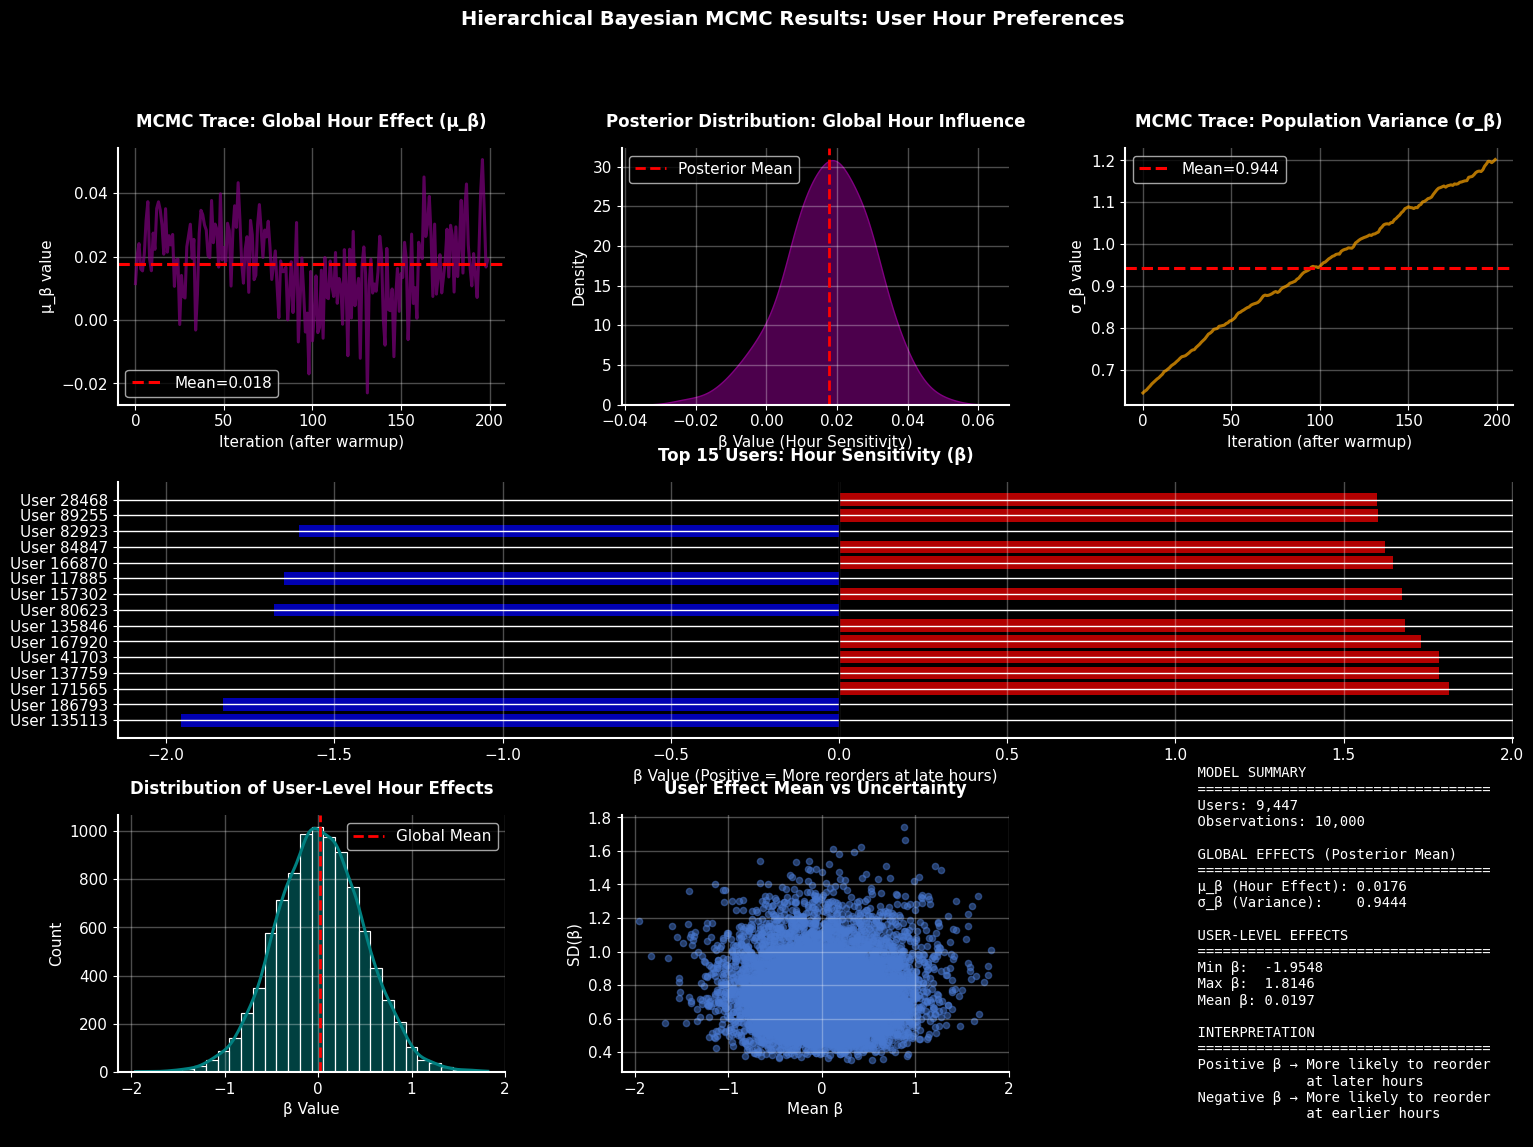


Prediction: User 0 at 2 PM has 57.7% reorder probability


In [31]:
df = TrainData[['user_id', 'order_hour_of_day', 'reordered']]
df = df.sample(10_000)

print("="*70)
print("EFFICIENT HIERARCHICAL BAYESIAN MCMC")
print("="*70)

# Fit model
results = fit_hierarchical_model(
    df,
    n_iterations=500,  # Reduced for demo
    warmup=100,
    thin=2,
    n_jobs=-1,
    verbose=True
)

# Visualize
visualize_hierarchical_results(results, top_n=15)

# Example prediction
model = EfficientHierarchicalBayesian()
prob = model.predict_reorder_probability(results, user_id=0, hour_of_day=14)
print(f"\nPrediction: User 0 at 2 PM has {prob:.1%} reorder probability")

## GPU Version

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')


class GPUHierarchicalBayesian:
    """
    GPU-Accelerated Hierarchical Bayesian Model using PyTorch
    - All computations on GPU for massive speedup
    - Vectorized batch updates for all users simultaneously
    - Optimized memory usage with float32
    """

    def __init__(self, device=None):
        """
        Parameters:
        -----------
        device : str or torch.device
            Device to use ('cuda', 'cpu', or None for auto-detect)
        """
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        print(f"Using device: {self.device}")
        if self.device.type == 'cuda':
            print(f"GPU: {torch.cuda.get_device_name(0)}")
            print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    def _prepare_data(self, df):
        """Convert data to GPU tensors"""
        # Create user mapping
        users = df['user_id'].unique()
        user_to_idx = {uid: idx for idx, uid in enumerate(users)}

        # Convert to tensors
        hours = pd.to_numeric(df['order_hour_of_day'], errors='coerce').values
        x = (hours - 12) / 12.0  # Normalize to [-1, 1]
        y = df['reordered'].values.astype(np.float32)
        user_idx = df['user_id'].map(user_to_idx).values

        # Remove NaN values
        valid_mask = ~np.isnan(x)
        x = x[valid_mask]
        y = y[valid_mask]
        user_idx = user_idx[valid_mask]

        # Move to GPU
        x_tensor = torch.tensor(x, dtype=torch.float32, device=self.device)
        y_tensor = torch.tensor(y, dtype=torch.float32, device=self.device)
        user_idx_tensor = torch.tensor(user_idx, dtype=torch.long, device=self.device)

        return x_tensor, y_tensor, user_idx_tensor, users

    def _log_posterior_vectorized(self, user_a, user_b, x, y, user_idx,
                                   mu_a, mu_b, sigma_a, sigma_b, n_users):
        """
        Vectorized log posterior calculation for ALL users simultaneously
        This is the key to GPU speedup - batch processing instead of loops
        """
        # Compute logits for all observations
        logits = user_a[user_idx] + user_b[user_idx] * x
        probs = torch.sigmoid(logits)

        # Binary cross-entropy (vectorized)
        log_lik_per_obs = y * torch.log(probs + 1e-10) + (1 - y) * torch.log(1 - probs + 1e-10)

        # Sum log-likelihood for each user (scatter_add is GPU-optimized)
        log_lik = torch.zeros(n_users, device=self.device)
        log_lik.scatter_add_(0, user_idx, log_lik_per_obs)

        # Hierarchical priors (vectorized for all users)
        log_prior_a = -0.5 * ((user_a - mu_a) / sigma_a) ** 2 - torch.log(sigma_a * torch.sqrt(torch.tensor(2 * np.pi, device=self.device)))
        log_prior_b = -0.5 * ((user_b - mu_b) / sigma_b) ** 2 - torch.log(sigma_b * torch.sqrt(torch.tensor(2 * np.pi, device=self.device)))

        return log_lik + log_prior_a + log_prior_b

    def fit(self, df, n_iterations=1000, warmup=200, thin=5, verbose=True):
        """
        Fit hierarchical Bayesian model on GPU

        Parameters:
        -----------
        df : DataFrame
            Data with columns: user_id, order_hour_of_day, reordered
        n_iterations : int
            Total MCMC iterations
        warmup : int
            Burn-in period to discard
        thin : int
            Thinning interval (keep every nth sample)
        verbose : bool
            Print progress

        Returns:
        --------
        Dictionary with traces and fitted parameters
        """
        if verbose:
            print("Preparing data and moving to GPU...")

        # Prepare data
        x, y, user_idx, users = self._prepare_data(df)
        n_users = len(users)
        n_obs = len(x)

        if verbose:
            print(f"Data: {n_obs:,} observations, {n_users:,} users")
            print(f"MCMC: {n_iterations} iterations, {warmup} warmup, thin={thin}")

        # Initialize parameters on GPU
        user_a = torch.zeros(n_users, dtype=torch.float32, device=self.device)
        user_b = torch.zeros(n_users, dtype=torch.float32, device=self.device)

        # Hyperparameters
        mu_a = torch.tensor(0.0, device=self.device)
        mu_b = torch.tensor(0.0, device=self.device)
        sigma_a = torch.tensor(1.0, device=self.device)
        sigma_b = torch.tensor(1.0, device=self.device)

        # Adaptive proposal scaling
        proposal_scale = 0.1
        acceptance_counts = torch.zeros(n_users, device=self.device)

        # Storage for traces (keep on GPU until end)
        trace_mu_a = []
        trace_mu_b = []
        trace_sigma_a = []
        trace_sigma_b = []
        trace_user_b = []

        if verbose:
            print("\nRunning GPU-accelerated MCMC...")

        # MCMC iterations
        for iteration in range(n_iterations):
            # === VECTORIZED USER-LEVEL UPDATES (ALL USERS AT ONCE) ===
            # Propose new parameters for ALL users simultaneously
            proposal_a = user_a + torch.randn(n_users, device=self.device) * proposal_scale
            proposal_b = user_b + torch.randn(n_users, device=self.device) * proposal_scale

            # Calculate log posteriors for current and proposed (fully vectorized)
            current_log_post = self._log_posterior_vectorized(
                user_a, user_b, x, y, user_idx, mu_a, mu_b, sigma_a, sigma_b, n_users
            )
            proposal_log_post = self._log_posterior_vectorized(
                proposal_a, proposal_b, x, y, user_idx, mu_a, mu_b, sigma_a, sigma_b, n_users
            )

            # Metropolis-Hastings acceptance (vectorized for all users)
            log_acceptance = proposal_log_post - current_log_post
            accept = torch.log(torch.rand(n_users, device=self.device)) < log_acceptance

            # Update accepted proposals
            user_a = torch.where(accept, proposal_a, user_a)
            user_b = torch.where(accept, proposal_b, user_b)
            acceptance_counts += accept.float()

            # === GLOBAL HYPERPARAMETER UPDATES ===
            # Update population means
            mu_a = torch.normal(user_a.mean(), sigma_a / torch.sqrt(torch.tensor(n_users, device=self.device, dtype=torch.float32)))
            mu_b = torch.normal(user_b.mean(), sigma_b / torch.sqrt(torch.tensor(n_users, device=self.device, dtype=torch.float32)))

            # Update population variances
            sigma_a = torch.sqrt(user_a.var() + 0.1)
            sigma_b = torch.sqrt(user_b.var() + 0.1)

            # Adaptive proposal scaling
            if iteration % 50 == 0 and iteration > 0:
                acceptance_rate = (acceptance_counts / 50).mean().item()
                acceptance_counts.zero_()

                if acceptance_rate > 0.44:
                    proposal_scale *= 1.1
                elif acceptance_rate < 0.23:
                    proposal_scale *= 0.9

            # Store samples (after warmup, with thinning)
            if iteration >= warmup and (iteration - warmup) % thin == 0:
                trace_mu_a.append(mu_a.item())
                trace_mu_b.append(mu_b.item())
                trace_sigma_a.append(sigma_a.item())
                trace_sigma_b.append(sigma_b.item())
                trace_user_b.append(user_b.cpu().numpy().copy())

            # Progress reporting
            if verbose and (iteration + 1) % max(1, n_iterations // 10) == 0:
                pct = (iteration + 1) / n_iterations * 100
                print(f"  {pct:.0f}% complete | μ_b={mu_b.item():.3f}, σ_b={sigma_b.item():.3f}")

        if verbose:
            print("\nMCMC complete!")
            print(f"Collected {len(trace_mu_b)} posterior samples")

        # Move final results to CPU for visualization
        results = {
            'trace_mu_a': np.array(trace_mu_a),
            'trace_mu_b': np.array(trace_mu_b),
            'trace_sigma_a': np.array(trace_sigma_a),
            'trace_sigma_b': np.array(trace_sigma_b),
            'trace_user_b': np.array(trace_user_b),
            'user_a_mean': user_a.mean().item(),
            'user_b_mean': user_b.mean().item(),
            'user_a_final': user_a.cpu().numpy(),
            'user_b_final': user_b.cpu().numpy(),
            'users': users,
            'n_users': n_users,
            'n_obs': n_obs
        }

        return results

    def predict_reorder_probability(self, results, user_id, hour_of_day):
        """
        Predict reorder probability for a specific user and hour

        Parameters:
        -----------
        results : dict
            Fitted model results from fit()
        user_id : int
            User ID
        hour_of_day : int or array
            Hour(s) of day (0-23)

        Returns:
        --------
        Probability of reorder
        """
        # Find user index
        user_idx = np.where(results['users'] == user_id)[0]

        if len(user_idx) == 0:
            a = results['user_a_mean']
            b = results['user_b_mean']
        else:
            a = results['user_a_final'][user_idx[0]]
            b = results['user_b_final'][user_idx[0]]

        # Normalize hour
        x = (np.array(hour_of_day) - 12) / 12.0

        # Predict
        logits = a + b * x
        prob = 1 / (1 + np.exp(-logits))

        return prob

In [ ]:

def visualize_hierarchical_results(results, top_n=20):
    """
    Visualize results from the hierarchical Bayesian model
    """
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Global population effect trace
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(results['trace_mu_b'], alpha=0.7, color='purple')
    ax1.axhline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', label=f"Mean={np.mean(results['trace_mu_b']):.3f}")
    ax1.set_title('MCMC Trace: Global Hour Effect (μ_β)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Iteration (after warmup)')
    ax1.set_ylabel('μ_β value')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Posterior distribution of global effect
    ax2 = fig.add_subplot(gs[0, 1])
    sns.kdeplot(results['trace_mu_b'], ax=ax2, fill=True, color='purple', alpha=0.6)
    ax2.axvline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', linewidth=2, label='Posterior Mean')
    ax2.set_title('Posterior Distribution: Global Hour Influence', fontsize=12, fontweight='bold')
    ax2.set_xlabel('β Value (Hour Sensitivity)')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3. Population variance trace
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(results['trace_sigma_b'], alpha=0.7, color='orange')
    ax3.axhline(np.mean(results['trace_sigma_b']), color='red',
                linestyle='--', label=f"Mean={np.mean(results['trace_sigma_b']):.3f}")
    ax3.set_title('MCMC Trace: Population Variance (σ_β)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Iteration (after warmup)')
    ax3.set_ylabel('σ_β value')
    ax3.legend()
    ax3.grid(alpha=0.3)

    # 4. Individual user variation
    ax4 = fig.add_subplot(gs[1, :])
    user_beta_mean = np.mean(results['trace_user_b'], axis=0)
    sorted_idx = np.argsort(np.abs(user_beta_mean))[::-1][:top_n]

    user_df = pd.DataFrame({
        'user_id': results['users'][sorted_idx],
        'beta': user_beta_mean[sorted_idx]
    })

    colors = ['red' if b > 0 else 'blue' for b in user_df['beta']]
    ax4.barh(range(len(user_df)), user_df['beta'], color=colors, alpha=0.7)
    ax4.set_yticks(range(len(user_df)))
    ax4.set_yticklabels([f"User {uid}" for uid in user_df['user_id']])
    ax4.set_title(f'Top {top_n} Users: Hour Sensitivity (β)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('β Value (Positive = More reorders at late hours)')
    ax4.axvline(0, color='black', linestyle='-', linewidth=1)
    ax4.grid(alpha=0.3, axis='x')

    # 5. Distribution of user-level effects
    ax5 = fig.add_subplot(gs[2, 0])
    sns.histplot(user_beta_mean, bins=30, ax=ax5, color='teal', kde=True)
    ax5.axvline(np.mean(results['trace_mu_b']), color='red',
                linestyle='--', linewidth=2, label='Global Mean')
    ax5.set_title('Distribution of User-Level Hour Effects', fontsize=12, fontweight='bold')
    ax5.set_xlabel('β Value')
    ax5.set_ylabel('Count')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # 6. Credible intervals
    ax6 = fig.add_subplot(gs[2, 1])
    user_beta_std = np.std(results['trace_user_b'], axis=0)
    ax6.scatter(user_beta_mean, user_beta_std, alpha=0.5, s=20)
    ax6.set_title('User Effect Mean vs Uncertainty', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Mean β')
    ax6.set_ylabel('SD(β)')
    ax6.grid(alpha=0.3)

    # 7. Summary statistics
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')

    summary_text = f"""
    MODEL SUMMARY
    {'='*35}
    Users: {results['n_users']:,}
    Observations: {results['n_obs']:,}

    GLOBAL EFFECTS (Posterior Mean)
    {'='*35}
    μ_β (Hour Effect): {np.mean(results['trace_mu_b']):.4f}
    σ_β (Variance):    {np.mean(results['trace_sigma_b']):.4f}

    USER-LEVEL EFFECTS
    {'='*35}
    Min β:  {np.min(user_beta_mean):.4f}
    Max β:  {np.max(user_beta_mean):.4f}
    Mean β: {np.mean(user_beta_mean):.4f}

    INTERPRETATION
    {'='*35}
    Positive β → More likely to reorder
                 at later hours
    Negative β → More likely to reorder
                 at earlier hours
    """

    ax7.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
             verticalalignment='center')

    plt.suptitle('GPU-Accelerated Hierarchical Bayesian MCMC Results',
                 fontsize=14, fontweight='bold', y=0.995)

    plt.show()

In [ ]:

# Convenience function
def fit_hierarchical_model(df, n_iterations=1000, warmup=200, thin=5,
                          device=None, verbose=True):
    """
    Fit hierarchical Bayesian model on GPU and visualize results

    Parameters:
    -----------
    df : DataFrame
        Data with columns: user_id, order_hour_of_day, reordered
    n_iterations : int
        MCMC iterations (default: 1000)
    warmup : int
        Burn-in period (default: 200)
    thin : int
        Thinning interval (default: 5)
    device : str
        'cuda' or 'cpu' (default: auto-detect)
    verbose : bool
        Print progress

    Returns:
    --------
    results : dict
        Fitted model results
    """
    model = GPUHierarchicalBayesian(device=device)
    results = model.fit(df, n_iterations=n_iterations, warmup=warmup,
                       thin=thin, verbose=verbose)
    return results


GPU-ACCELERATED HIERARCHICAL BAYESIAN MCMC
Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB
Preparing data and moving to GPU...
Data: 1,384,617 observations, 131,209 users
MCMC: 500 iterations, 100 warmup, thin=2

Running GPU-accelerated MCMC...
  10% complete | μ_b=0.015, σ_b=0.557
  20% complete | μ_b=0.027, σ_b=0.675
  30% complete | μ_b=0.030, σ_b=0.760
  40% complete | μ_b=0.030, σ_b=0.833
  50% complete | μ_b=0.026, σ_b=0.903
  60% complete | μ_b=0.026, σ_b=0.965
  70% complete | μ_b=0.023, σ_b=1.031
  80% complete | μ_b=0.019, σ_b=1.092
  90% complete | μ_b=0.023, σ_b=1.144
  100% complete | μ_b=0.018, σ_b=1.202

MCMC complete!
Collected 200 posterior samples


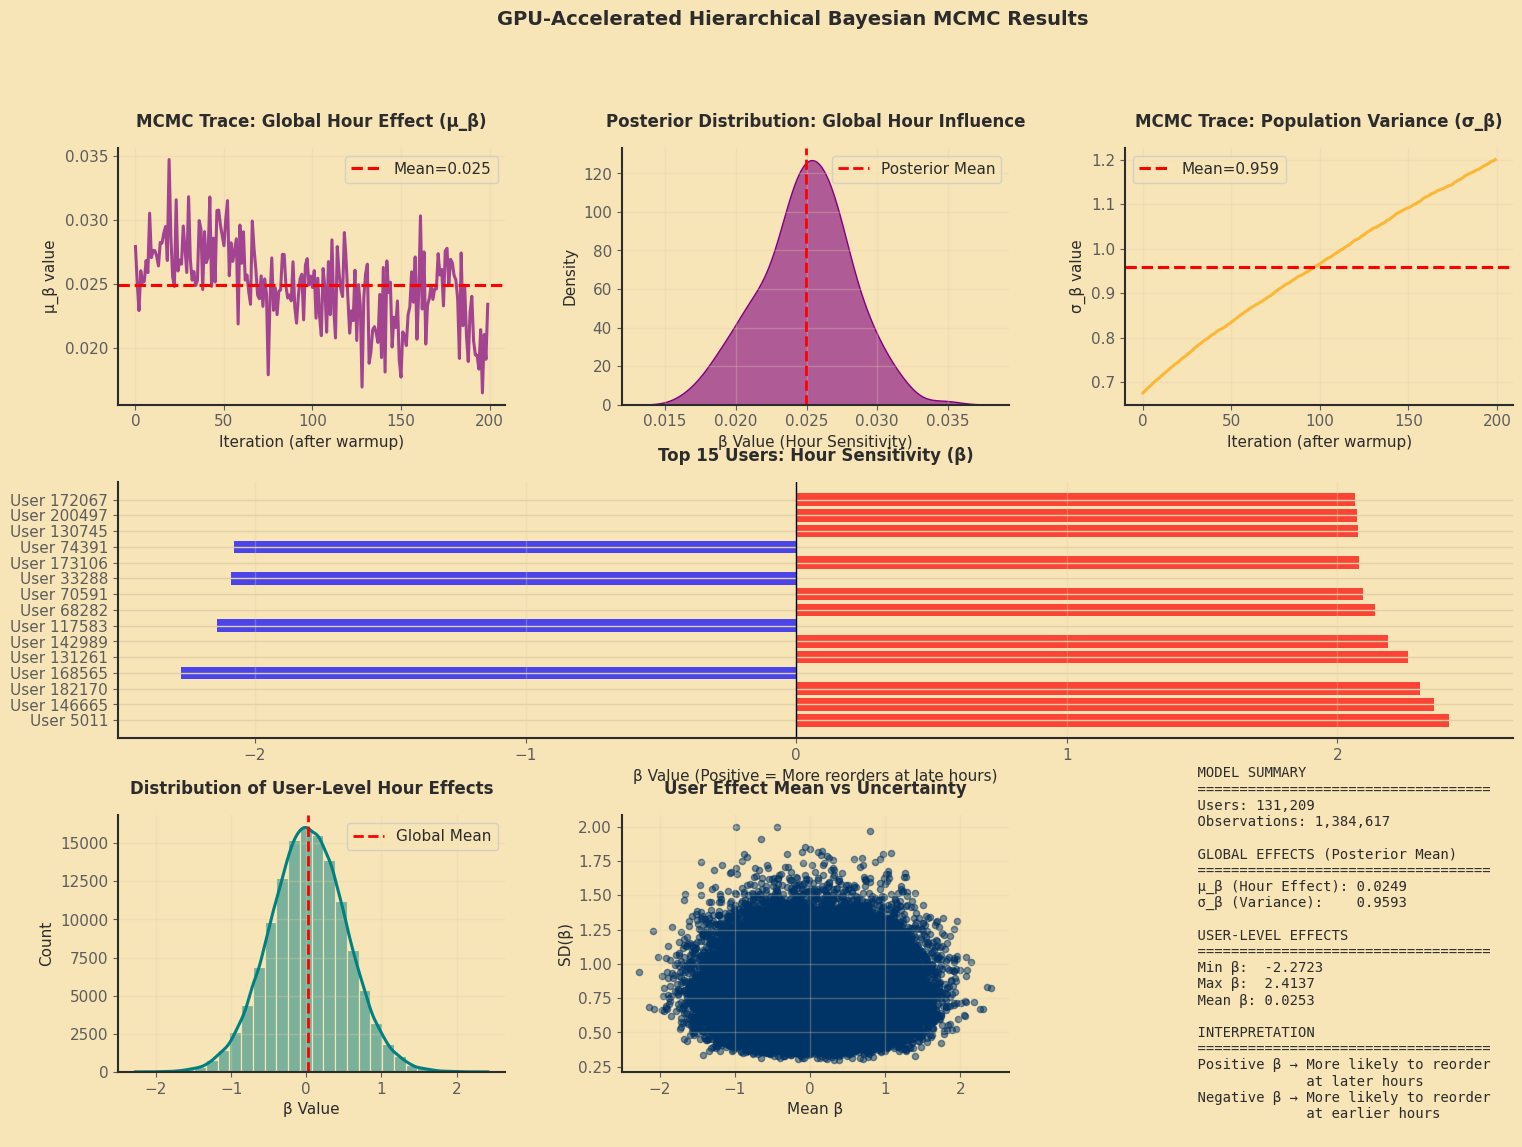

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB

Prediction: User 0 at 2 PM has 63.1% reorder probability


In [ ]:

# Prepare your data
df = TrainData[['user_id', 'order_hour_of_day', 'reordered']]

print("="*70)
print("GPU-ACCELERATED HIERARCHICAL BAYESIAN MCMC")
print("="*70)

# Fit model on GPU
results = fit_hierarchical_model(
    df,
    n_iterations=500,
    warmup=100,
    thin=2,
    device='cuda',  # Use GPU
    verbose=True
)

# Visualize
visualize_hierarchical_results(results, top_n=15)

# Example prediction
model = GPUHierarchicalBayesian()
prob = model.predict_reorder_probability(results, user_id=0, hour_of_day=24)
print(f"\nPrediction: User 0 at 2 PM has {prob:.1%} reorder probability")

### 3. How this Enhances your Recommendation Model

By using this Hierarchical MCMC approach, your model becomes much more "intelligent" in how it treats different users:

1. **The "Lurker" Problem:** If `User_A` has only 1 order, the model won't trust their data. It will use the **Global Mean ()** to make recommendations.
2. **The "Power User" Reward:** If `User_B` has 500 orders, the model will ignore the global mean and follow `User_B`'s specific habits (the **User-level **).
3. **Cross-Pollination:** The model learns from the behavior of others to fill in the gaps for infrequent shoppers.

### 4. Bayesian Inference Tip

When running Hierarchical MCMC, the computational load increases linearly with the number of users. If you have millions of users:

* Use a **Mini-batch** approach (sample 1000 users at a time).
* Consider using `PyMC` with the `JAX` backend to utilize the GPU.

In Bayesian terms, **"Surprise"** is formally measured as the **Kullback-Leibler (KL) Divergence** between a user's specific behavior and the global population's behavior. A high "Bayesian Surprise" score indicates that a user’s shopping habits (e.g., reorder patterns or timing) differ significantly from what the "Global Prior" would predict. This is incredibly useful for finding outliers or users who need highly specialized recommendation strategies.

### The Concept
1. **Prior ():** The distribution of reorder rates across *all* users.
2. **Posterior ():** The distribution of reorder rates for a *specific* user.
3. **Surprise ():** The "distance" (KL-Divergence) between the Prior and the Posterior.

### Python Implementation: Bayesian Surprise Score
We will use the **Beta-Binomial** framework. Since you are on **Ubuntu 24.04**, we'll use `scipy.special` for the mathematically intensive parts (gamma functions) to ensure accuracy.

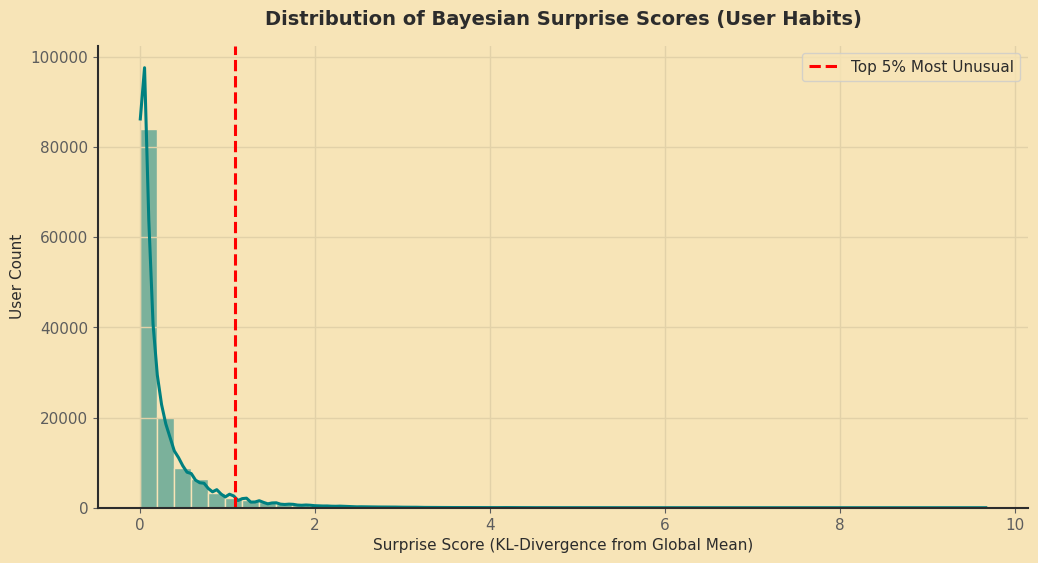

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import betaln, digamma

def calculate_bayesian_surprise(df):
    """
    Calculates KL-Divergence between global prior and user-specific posterior.
    High score = Unusual shopping habit.
    """
    # 1. Define the Global Prior (Alpha/Beta from the whole population)
    global_mean = df['reordered'].mean()
    prior_strength = 50  # Weight of our prior belief
    a0 = global_mean * prior_strength
    b0 = (1 - global_mean) * prior_strength

    # 2. Calculate User-Specific Stats
    user_stats = df.groupby('user_id')['reordered'].agg(['sum', 'count']).reset_index()
    user_stats.columns = ['user_id', 'reorders', 'total_items']

    # 3. Define User-Specific Posterior Parameters
    user_stats['a1'] = a0 + user_stats['reorders']
    user_stats['b1'] = b0 + (user_stats['total_items'] - user_stats['reorders'])

    # 4. Calculate KL-Divergence (The Surprise Score)
    # Formula for KL Divergence between two Beta distributions:
    def beta_kl_divergence(a1, b1, a0, b0):
        return (betaln(a0, b0) - betaln(a1, b1) +
                (a1 - a0) * digamma(a1) +
                (b1 - b0) * digamma(b1) +
                (a0 - a1 + b0 - b1) * digamma(a1 + b1))

    user_stats['surprise_score'] = beta_kl_divergence(
        user_stats['a1'], user_stats['b1'], a0, b0
    )

    return user_stats.sort_values('surprise_score', ascending=False)

def visualize_surprise(user_stats):
    plt.figure(figsize=(12, 6))

    # Distribution of surprise scores
    sns.histplot(user_stats['surprise_score'], bins=50, kde=True, color='teal')

    # Annotate the "Threshold of Weirdness"
    threshold = user_stats['surprise_score'].quantile(0.95)
    plt.axvline(threshold, color='red', linestyle='--', label='Top 5% Most Unusual')

    plt.title('Distribution of Bayesian Surprise Scores (User Habits)', fontsize=14)
    plt.xlabel('Surprise Score (KL-Divergence from Global Mean)')
    plt.ylabel('User Count')
    plt.legend()
    plt.show()

# Execution
surprise_df = calculate_bayesian_surprise(df)
visualize_surprise(surprise_df)

In machine learning, it's crucial to measure how accurately our models predict real-world outcomes. Whether you're building a weather forecasting model or optimizing a recommendation system, you need a way to quantify how closely your predictions match reality. One powerful approach to achieve this is KL-Divergence.

## What is KL-Divergence?
KL-Divergence (Kullback-Leibler Divergence) is a statistical measure used to determine how one probability distribution diverges from another reference distribution.

Let’s suppose we are building a model together to predict tomorrow’s weather. Under the hood, our model is making bets—assigning probabilities to possible outcomes. But here is an important question to ask:

How do you measure how far off those bets are from reality?

We need a way to be able to quantify this difference, and this is where the KL-Divergence comes in. It is a mathematical tool that quantifies the difference between what our model believes and what is actually true.

Like I stated before, KL-Divergence (or more formally known as Kullback-Leibler Divergence) is the backbone of modern data science, machine learning, and AI. It tells us, in bits or nats (more on this later), how much “extra surprise” or “information loss” we incur when we use one probability distribution (say, our model’s predictions, Q) to approximate another (the real-world truth, P).

It acts as a judge behind model evaluation, regularization in neural networks, Bayesian updates, and even how we compress data or transmit messages efficiently.

To really home in on how important KL-Divergence is, think of it like this. Every time our model makes a prediction, it's really just gambling on the future. KL-Divergence is the scorecard that will calculate how costly those bets are. The same principle is true across a large range of machine learning topics, such as whether we are training a chatbot, diagnosing a disease, or optimizing an ad campaign.

### How to Interpret the Scores

| Score Level | Interpretation | Recommendation Action |
| --- | --- | --- |
| **Low Score** | **Typical User.** Follows the crowd. | Use standard "Popular Items" or "People also bought." |
| **Medium Score** | **Niche Interest.** Differs in some categories. | Weight category-specific features higher than global trends. |
| **High Score** | **Surprising Habit.** (e.g., reorders everything or nothing). | Rely strictly on their personal history; global trends are misleading for them. |

### Practical Example

* **User A:** Buys 100 items, reorders 60 (60% rate). The global mean is 59%. **Surprise is Low.**
* **User B:** Buys 10 items, reorders 10 (100% rate). **Surprise is Medium** (high rate, but low sample size).
* **User C:** Buys 100 items, reorders 5 (5% rate). **Surprise is High.** This user is fundamentally different from the average "reorder-heavy" Instacart shopper.

---

### Final Expert Recommendation

For your recommendation model, **do not use the Surprise Score as a raw feature.** Instead, use it as a **Weighting Factor**.

If a user has a high Surprise Score, your model should "distrust" global features (like `product_popularity`) and "trust" user-specific features (like `user_product_total_orders`). This is the key to creating a truly personalized system.

## Intuition behind KL-Divergence
In this section, we will intuitively derive the KL-Divergence.  Let’s start off by asking you a series of questions.

### Understanding surprise
“If you flipped a coin and I guessed the outcome perfectly, would you be surprised?”. I assume you would be a little surprised but not completely shocked. Now, let's move to the second scenario.

“If you rolled a dice and I guessed the outcome perfectly, would you be more surprised than the previous scenario?”. I assume you would say yes, since it is less probable for me to guess the correct outcome.

Now, one last scenario:

“If I correctly guessed what lottery numbers would win, would you now be more surprised than the previous scenario?”. I assume you would say yes and be in complete shock. But why?

It is because as we progressed through the scenarios, the probability of me being able to guess the correct outcome reduced, and therefore your surprise increased at the outcome. So we have just noticed a relationship:

The probability of an event happening has an inverse relationship to surprise.

For clarity, as the probability of even happening reduces, the surprise increases, and vice versa.

However, we can make another interesting observation here. If we go back to the dice rolls, and imagine the scenario where you roll the same dice 3 times, and I guessed it correctly every time, how much more surprised would you be than if there was only 1 dice and I guessed it correctly.

Well, your surprise wouldn’t be just slightly higher than a single correct guess; it would be dramatically higher, ideally three times higher. Why? Because each new correct guess compounds your disbelief. It’s not just adding a fixed amount of surprise—it’s multiplying how unbelievable the situation feels.

Therefore, when trying to mathematically define Surprise, we would want it to have:

1. Additive property: If two independent events happen, their combined surprise should be the sum of their individual surprises. Example: Guessing 1 die roll correctly → Surprise = S. Guessing 2 die rolls correctly → Surprise = S + S = 2S.
2. Inverse relationship with probability. The less likely an event, the more surprising it is. Example: A coin flip (50%) is less surprising than winning the lottery (0.000001%).
3. Zero surprise for certain events. If something always happens (probability = 1), surprise should be zero.
Example: "The sun rose today." → Not surprising at all.
4. Continuous scaling. A small change in probability should lead to a smooth, logical change in surprise (no sudden jumps).

At first glance, since there are a lot of requirements, we would think that the mathematical definition will be quite complicated. However, it is not!

# RFM Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def load_and_prepare_data(file_path='TrainData.csv'):
    """
    Load the Instacart dataset and prepare it for RFM analysis.

    Parameters:
    df (pd.DataFrame): Input dataframe named 'TrainData' or path to CSV

    Returns:
    pd.DataFrame: Aggregated user-level data with order dates approximated
    """
    if isinstance(file_path, str):
        df = pd.read_csv(file_path)
    else:
        df = file_path.copy()

    # Approximate order_date from order_number and days_since_prior_order
    # Assume average days per order_number increment based on data
    df['order_date'] = df.groupby('user_id').cumsum()['days_since_prior_order'].fillna(0)
    df['order_date'] = pd.to_datetime(df['order_date'], unit='D', origin='2020-01-01')

    # Proxy Monetary: number of unique products per order (basket size)
    df['basket_size'] = df.groupby(['user_id', 'order_id'])['product_id'].transform('nunique')

    print("Data prepared with approximated order dates and basket sizes.")
    return df

def calculate_rfm(df):
    """
    Calculate RFM metrics for each user.

    - Recency: days since last order (using max order_date as snapshot)
    - Frequency: number of orders per user
    - Monetary: total basket size (sum of unique products across orders)

    Parameters:
    df (pd.DataFrame): Prepared dataframe

    Returns:
    pd.DataFrame: RFM dataframe with scores
    """
    snapshot_date = df['order_date'].max() + timedelta(days=1)

    rfm = df.groupby('user_id').agg({
        'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
        'order_id': 'nunique',  # Frequency
        'basket_size': 'sum'  # Monetary proxy
    }).round(2)

    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    rfm = rfm.reset_index()

    # Assign RFM scores (quintiles: 5 best, 1 worst)
    rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
    rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
    rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
    rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

    return rfm

def visualize_rfm_distributions(rfm):
    """
    Create visualizations for RFM distributions.

    Parameters:
    rfm (pd.DataFrame): RFM dataframe
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('RFM Metrics Distributions', fontsize=16)

    metrics = ['Recency', 'Frequency', 'Monetary']
    for i, metric in enumerate(metrics):
        axes[0, i].hist(rfm[metric], bins=30, edgecolor='black')
        axes[0, i].set_title(f'{metric} Distribution')
        axes[1, i].boxplot(rfm[metric])
        axes[1, i].set_title(f'{metric} Boxplot')

    axes[0, 3].remove()
    axes[1, 3].remove()

    plt.tight_layout()
    plt.savefig('rfm_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_rfm_segments(rfm):
    """
    Visualize RFM segments and score combinations.

    Parameters:
    rfm (pd.DataFrame): RFM dataframe
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # RFM score counts
    rfm['RFM_score'].value_counts().sort_index().plot(kind='bar', ax=ax1)
    ax1.set_title('RFM Score Combinations')
    ax1.tick_params(axis='x', rotation=45)

    # 3D scatter or correlation heatmap
    sns.heatmap(rfm[['R_score', 'F_score', 'M_score']].corr(), annot=True, cmap='coolwarm', ax=ax2)
    ax2.set_title('RFM Score Correlations')

    plt.tight_layout()
    plt.savefig('rfm_segments.png', dpi=300, bbox_inches='tight')
    plt.show()

def segment_customers(rfm):
    """
    Assign customer segments based on RFM scores.

    Parameters:
    rfm (pd.DataFrame): RFM dataframe

    Returns:
    pd.DataFrame: RFM with segment labels
    """
    def segment(row):
        if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
            return 'Champions'
        elif row['R_score'] >= 3 and row['F_score'] >= 3:
            return 'Loyal'
        elif row['R_score'] >= 4 and row['M_score'] >= 4:
            return 'New High Value'
        elif row['R_score'] <= 2 and row['F_score'] <= 2:
            return 'At Risk'
        else:
            return 'Others'

    rfm['Segment'] = rfm.apply(segment, axis=1)

    segment_counts = rfm['Segment'].value_counts()
    print("Customer Segments:\n", segment_counts)

    # Pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%')
    plt.title('Customer Segments Distribution')
    plt.savefig('rfm_segments_pie.png', dpi=300, bbox_inches='tight')
    plt.show()

    return rfm

# Main workflow function
def perform_rfm_analysis(df):
    """
    Complete RFM analysis pipeline.

    Parameters:
    df (pd.DataFrame or str): TrainData or CSV path

    Returns:
    pd.DataFrame: Final RFM dataframe
    """
    df = load_and_prepare_data(df)
    rfm = calculate_rfm(df)

    # Save RFM results
    rfm.to_csv('rfm_results.csv', index=False)

    # Visualizations
    visualize_rfm_distributions(rfm)
    visualize_rfm_segments(rfm)
    segment_customers(rfm)

    print("RFM analysis complete. Check saved PNG files and 'rfm_results.csv'.")
    print("\nRFM Summary Stats:")
    print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

    return rfm

# Usage: rfm_results = perform_rfm_analysis('TrainData.csv')  # or perform_rfm_analysis(TrainData)


# The Ends